# Эквивариантное предсказание молекулярных тензоров: дипольный вектор и поляризуемость

Предсказание **векторных** и **тензорных** свойств молекул с явным учётом симметрий пространства,
и проверка того, могут ли топологические признаки что-то к этому добавить.

**Задача.** Для молекулы, заданной набором атомов $\{(Z_i, \mathbf{r}_i)\}$, предсказать:
- дипольный момент $\boldsymbol{\mu} \in \mathbb{R}^3$ — тензор **ранга 1**;
- тензор поляризуемости $\alpha \in \mathbb{R}^{3\times3}$ (симметричный, 6 независимых компонент) — тензор **ранга 2**.

**Центральное требование — эквивариантность.** При повороте молекулы $R \in SO(3)$ предсказания
обязаны преобразовываться по своим представлениям группы:

$$\boldsymbol{\mu}(R\mathbf{r}) = R\,\boldsymbol{\mu}(\mathbf{r}), \qquad \alpha(R\mathbf{r}) = R\,\alpha(\mathbf{r})\,R^{\top}$$

Модель, предсказывающая 3 числа обычной `Linear`-головой поверх инвариантных эмбеддингов, это
свойство нарушает: повернём молекулу — предсказание не повернётся. Мы строим головы так, чтобы
эквивариантность выполнялась **по конструкции**, и затем проверяем это численно.

**Что исследуется.**
1. Насколько физически мотивированная эквивариантная конструкция выигрывает у неэквивариантных бейзлайнов.
2. Обобщается ли она с ранга 1 на ранг 2.
3. Добавляют ли что-нибудь топологические признаки (персистентные гомологии $H_0/H_1$) — и почему
   ответ на этот вопрос можно предсказать заранее из теории представлений.

**Данные: QM9S** ([figshare](https://figshare.com/articles/dataset/QM9S_dataset/24235333)), 129 817 молекул.

> **Почему не Alchemy.** Постановка требует дипольного *вектора* и *3×3 тензора*. В статье Alchemy
> эти величины заявлены, и код `alchemy-pyscf` их вычисляет, но в публичном релизе target-файлы
> содержат только 12 скалярных свойств (тот же набор, что в QM9): `mu` — это **модуль** диполя,
> `alpha` — **изотропная** поляризуемость. Векторных и тензорных меток в релизе нет, а пересчёт
> 119k молекул на уровне B3LYP/6-31G(2df,p) выходит за рамки проекта. Проверка колонок релиза —
> в разделе 2. QM9S даёт и вектор, и 6 компонент тензора при сопоставимом уровне теории.

In [1]:
!pip install torch-geometric -q
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.11.0+cu128.html -q
!pip install gudhi -q
!pip install matplotlib numpy pandas rdkit tqdm scikit-learn scipy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 18.0 MB/s eta 0:00:00


In [2]:
import os, math, random, json, time, warnings, pickle
import numpy as np
import pandas as pd
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from tqdm.auto import tqdm

# Кэш тяжёлых вычислений. В Colab с примонтированным Drive переживает перезапуск
# сессии; иначе живёт только в её пределах. Отсутствие кэша не мешает работе —
# каждая длинная ячейка при промахе просто считает всё заново и сохраняет результат.
_DRIVE = os.path.ismount('/content/drive')
CACHE_DIR = '/content/drive/MyDrive/emt_cache' if _DRIVE else './emt_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

warnings.filterwarnings('ignore', category=UserWarning)

# ---------------------------------------------------------------- конфигурация
CFG = {
    'n_molecules': 50_000,      # из 129_817
    'seeds':       [0, 1, 2],   # для абляции с разбросом
    'epochs':      30,
    'batch_size':  32,
    'lr':          1e-3,
    'hidden':      64,
    'cutoff':      5.0,         # Å, радиус графа SchNet
    'tda_max_edge': 2.5,        # Å; подобрано по corr(H1, кольца) — см. раздел 4.1
    'split':       (0.7, 0.1, 0.2),   # train / val / test
    'data_dir':    '/content/qm9s/qm9s_csv/',
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Кэш: {CACHE_DIR}"
      + ("" if _DRIVE else "   (Drive не смонтирован - кэш не переживёт перезапуск сессии)"))
print(f"Устройство: {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))

# ------------------------------------------------------------- визуальный стиль
mpl.rcParams.update({
    'figure.dpi':        110,
    'savefig.dpi':       200,
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.titleweight':  'semibold',
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linewidth':    0.6,
    'legend.frameon':    False,
    'figure.facecolor':  'white',
})

# Палитра проекта: тёплая для "истины", холодная для "предсказания"
C = {
    'true':    '#2B3A67',   # тёмно-синий  — истинные значения
    'pred':    '#C1444C',   # приглушённый красный — предсказания
    'accent':  '#E08D3C',   # янтарный — акценты, TDA
    'neutral': '#8A8F98',   # серый — вспомогательное
    'good':    '#3B7D4F',   # зелёный — пройденные тесты
}

# CPK-палитра: стандартные цвета атомов в химической визуализации
CPK_COLOR  = {1: '#F2F2F2', 6: '#3C3C3C', 7: '#3050F8', 8: '#FF2010', 9: '#90E050'}
CPK_RADIUS = {1: 60,        6: 170,       7: 155,       8: 152,       9: 147}   # ~ковалентные, пм
CPK_SYMBOL = {1: 'H',       6: 'C',       7: 'N',       8: 'O',       9: 'F'}

def atom_style(z_array, size_scale=1.0):
    """Цвета и размеры маркеров для 3D-визуализации молекулы по атомным номерам."""
    z_array = np.asarray(z_array, dtype=int)
    colors = [CPK_COLOR.get(int(z), '#B050D0') for z in z_array]
    sizes  = [CPK_RADIUS.get(int(z), 150) * size_scale for z in z_array]
    return colors, sizes

# Дивергентная карта для атомных зарядов: отрицательный -> красный, положительный -> синий
CHARGE_CMAP = LinearSegmentedColormap.from_list(
    'charge', ['#C1444C', '#F5F5F5', '#3050F8'])

def set_seed(seed):
    """Фиксация всех источников случайности — нужно для воспроизводимой абляции."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Стиль и палитра заданы.")

Кэш: ./emt_cache   (Drive не смонтирован - кэш не переживёт перезапуск сессии)
Устройство: cuda (Tesla T4)
Стиль и палитра заданы.


## 2. Данные

QM9S: 129 817 молекул, по одному CSV-файлу на молекулу. Каждый файл содержит геометрию
(координаты + атомные номера), дипольный момент в виде **вектора** $(\mu_x, \mu_y, \mu_z)$ в Debye
и тензор поляризуемости в виде 6 независимых компонент $(\alpha_{xx}, \alpha_{xy}, \alpha_{yy},
\alpha_{zx}, \alpha_{zy}, \alpha_{zz})$ в Bohr³.

Важно, что **и вектор, и тензор заданы в той же лабораторной системе координат, что и координаты
атомов** — именно это делает задачу эквивариантной, а не инвариантной: таргет привязан к ориентации
молекулы в пространстве.

In [19]:
from google.colab import drive
drive.mount('/content/drive')

# Архив qm9s_csv.zip предварительно загружен на Google Drive
# Источник: https://figshare.com/articles/dataset/QM9S_dataset/24235333
ARCHIVE = '/content/drive/MyDrive/qm9s_csv.zip'

if not os.path.exists(CFG['data_dir']):
    !unzip -q {ARCHIVE} -d /content/qm9s/
else:
    print("Данные уже распакованы, пропускаем.")

# ------------------------------------------------------------------ инвентаризация
all_files = sorted(os.listdir(CFG['data_dir']))
print(f"Всего файлов в датасете: {len(all_files):,}")
print(f"Будет использовано:      {CFG['n_molecules']:,} "
      f"({100 * CFG['n_molecules'] / len(all_files):.0f}% датасета)")

# Смотрим сырую структуру одного файла — без этого парсер ниже выглядит как магия
sample_path = os.path.join(CFG['data_dir'], all_files[0])
print(f"\n{'─' * 70}\nСырая структура файла {all_files[0]}:\n{'─' * 70}")
with open(sample_path) as f:
    for i, line in enumerate(f):
        if i > 14:
            print("   ...")
            break
        tag = {1: '  <- метаданные (номер, SMILES, N атомов)',
               4: '  <- ДИПОЛЬНЫЙ ВЕКТОР (x, y, z), Debye',
               7: '  <- ПОЛЯРИЗУЕМОСТЬ (xx, xy, yy, zx, zy, zz), Bohr^3',
               11: '  <- начало блока координат: Z, x, y, z (Angstrom)'}.get(i, '')
        print(f"{i:>3} | {line.rstrip()[:60]:<60}{tag}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Всего файлов в датасете: 129,817
Будет использовано:      50,000 (39% датасета)

──────────────────────────────────────────────────────────────────────
Сырая структура файла 000001.csv:
──────────────────────────────────────────────────────────────────────
  0 | ,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,
  1 | 0,1.0,1.0,C,5.0,,,,,,,,,,,,,,,,,,,,,,,,,,                     <- метаданные (номер, SMILES, N атомов)
  2 | 1,-1103.069580078125,,,,,,,,,,,,,,,,,,,,,,,,,,,,,           
  3 | 2,-0.8297299742698669,0.20743000507354736,0.2074300050735473
  4 | 3,0.0,0.0,0.0,,,,,,,,,,,,,,,,,,,,,,,,,,,                      <- ДИПОЛЬНЫЙ ВЕКТОР (x, y, z), Debye
  5 | 4,-8.503000259399414,-0.0,-8.503000259399414,0.0,0.0,-8.5030
  6 | 5,0.8827999830245972,-8.817700386047363,0.13009999692440033,
  7 | 6,14.45680046081543,0.0,14.45680046081543,0.0,1.280089963984

### 2.1. Верификация выбора датасета

Постановка задачи называет Alchemy. Прежде чем от неё отступать, проверим утверждение
«в публичном релизе нет векторных меток» по исходникам, а не по памяти.

In [20]:
import urllib.request

# Официальный загрузчик Alchemy (репозиторий из презентации курса).
# Читаем сам код даталоадера — он показывает, какие колонки есть в target-файлах релиза.
LOADER_URL = ('https://raw.githubusercontent.com/tencent-alchemy/'
              'Alchemy/master/pyg/Alchemy_dataset.py')

try:
    src = urllib.request.urlopen(LOADER_URL, timeout=15).read().decode()
    print(f"Загружен официальный даталоадер ({len(src)} символов)\n")

    # Ищем строки, где читаются целевые значения
    for line in src.split('\n'):
        low = line.lower()
        if any(k in low for k in ('target', '.csv', 'mu', 'alpha', 'columns', 'iloc')):
            print('   ', line.strip()[:100])
except Exception as e:
    print(f"Не удалось получить файл автоматически ({e}).")
    print(f"Откройте вручную: {LOADER_URL}")
    print("Если путь изменился - репозиторий: https://github.com/tencent-alchemy/Alchemy")

print(f"\n{'─' * 70}")


Загружен официальный даталоадер (6589 символов)

    '/dev_target.csv'] if self.mode == 'dev' else [
    # for training set, we store its target
    l = torch.FloatTensor(self.target.loc[int(sdf_file.stem)].tolist()).unsqueeze(0) \
    self.target = pd.read_csv(self.raw_paths[1],
    self.target = self.target[['property_%d' % x for x in range(12)]]

──────────────────────────────────────────────────────────────────────


**Вывод по составу релиза Alchemy.**

Публичный релиз (`dev.zip` / `valid.zip`, скачиваются скриптом `pyg/data-bin/download.sh`)
содержит SDF-файлы с геометрией и target-файл с **12 скалярными свойствами** — тем же набором,
что в QM9: `mu`, `alpha`, `HOMO`, `LUMO`, `gap`, `R2`, `ZPVE`, `U0`, `U`, `H`, `G`, `Cv`.
Здесь `mu` — это **модуль** дипольного момента (одно число, Debye), а `alpha` — **изотропная**
поляризуемость (одно число, Bohr³).

Дипольный **вектор** и 3×3 **тензор** в релизе отсутствуют, хотя статья
([arXiv:1906.09427](https://arxiv.org/abs/1906.09427)) заявляет, что они вычислялись, а код
генерации `alchemy-pyscf` содержит поля `dipole_vector` и `polarizability_tensor`.
Дополнительно: в рамках соревнования все свойства опубликованы нормированными (вычтено среднее,
поделено на std), что само по себе исключает восстановление физических векторных величин.

Для эквивариантной постановки (головы ранга 1 и ранга 2) скалярных редукций недостаточно —
обучать не на чем. Пересчёт ~119k молекул через `alchemy-pyscf` на уровне B3LYP/6-31G(2df,p)
выходит за рамки проекта.

**Поэтому эксперименты выполнены на QM9S**, где дипольный вектор (3 компоненты) и тензор
поляризуемости (6 независимых компонент) присутствуют явно.

### 2.2. Парсер

Собираем из CSV четыре объекта: атомные номера $Z_i$, координаты $\mathbf{r}_i$ (Å),
дипольный вектор $\boldsymbol{\mu}$ (Debye) и тензор поляризуемости $\alpha$ (Bohr³).

Тензор хранится шестью независимыми компонентами (нижний треугольник) и восстанавливается как

$$\alpha = \begin{pmatrix} \alpha_{xx} & \alpha_{xy} & \alpha_{zx} \\ \alpha_{xy} & \alpha_{yy} & \alpha_{zy} \\ \alpha_{zx} & \alpha_{zy} & \alpha_{zz}\end{pmatrix}$$

Правильность сборки проверяется физикой, а не глазами: для основного состояния $\alpha$ обязан быть
**симметричным и положительно определённым** (молекула поляризуется *вдоль* приложенного поля).
Если бы порядок компонент был перепутан, собственные значения ушли бы в минус.

In [21]:
VALID_Z = {1, 6, 7, 8, 9}

def parse_molecule(path):
    """Разбор CSV QM9S.

    Структура (col0 — служебный индекс в колонке 0):
        col0=0  : id | ? | SMILES | n_atoms
        col0=1  : полная энергия (скаляр)
        col0=2  : атомные заряды Löwdin (n_atoms значений)
        col0=3  : дипольный вектор (3), Debye
        col0=4  : тензор вторых моментов (6); след = R²
        col0=6  : ТЕНЗОР ПОЛЯРИЗУЕМОСТИ (6): xx, xy, yy, zx, zy, zz, Bohr³
        col0=10+: координаты (n_atoms строк): Z | x | y | z, Angstrom
    """
    df = pd.read_csv(path, header=None)

    # col0 = i  <->  позиция строки i+1 (строка 0 — заголовок)
    def row(c):
        return df.iloc[c + 1]

    n_atoms = int(float(row(0).iloc[4]))
    smiles  = str(row(0).iloc[3])

    charges = row(2).iloc[1:1 + n_atoms].to_numpy(dtype=np.float32)
    mu      = row(3).iloc[1:4].to_numpy(dtype=np.float32)

    xx, xy, yy, zx, zy, zz = row(6).iloc[1:7].to_numpy(dtype=np.float32)
    alpha = np.array([[xx, xy, zx],
                      [xy, yy, zy],
                      [zx, zy, zz]], dtype=np.float32)

    block = df.iloc[11:11 + n_atoms]
    z   = block.iloc[:, 1].to_numpy(dtype=np.float64).round().astype(np.int64)
    pos = block.iloc[:, 2:5].to_numpy(dtype=np.float32)

    if len(z) != n_atoms or not set(z.tolist()) <= VALID_Z:
        raise ValueError(f'битый блок координат: {z.tolist()}')
    if not np.all(np.isfinite(pos)):
        raise ValueError('нечисловые координаты')

    return {'z': z, 'pos': pos, 'mu': mu, 'alpha': alpha,
            'charges': charges, 'n_atoms': n_atoms, 'smiles': smiles}


# ------------------------------------------------------------- контроль физики
print("Контроль на 300 молекулах\n" + '─' * 70)
sizes, ok = [], {'сумма зарядов ≈ 0': 0, 'α симметричен': 0,
                 'α положит. определён': 0, 'Z из {H,C,N,O,F}': 0}

for f in all_files[:300]:
    m = parse_molecule(os.path.join(CFG['data_dir'], f))
    sizes.append(m['n_atoms'])
    ok['сумма зарядов ≈ 0']    += abs(m['charges'].sum()) < 1e-2
    ok['α симметричен']         += np.allclose(m['alpha'], m['alpha'].T, atol=1e-6)
    ok['α положит. определён']  += bool(np.all(np.linalg.eigvalsh(m['alpha']) > 0))
    ok['Z из {H,C,N,O,F}']      += set(m['z'].tolist()) <= VALID_Z

for k, v in ok.items():
    print(f"  {'✓' if v == 300 else '✗'} {k:<24} {v}/300")

sizes = np.array(sizes)
print(f"\n  атомов: min={sizes.min()}, max={sizes.max()}, среднее={sizes.mean():.1f}")
print(f"  уникальных размеров: {len(np.unique(sizes))}")

# Эталонная проверка на воде
w = parse_molecule(os.path.join(CFG['data_dir'], '000003.csv'))
print(f"\n  H₂O: |μ| = {np.linalg.norm(w['mu']):.3f} D (ожидаем ≈2.1), "
      f"iso(α) = {np.trace(w['alpha']) / 3:.2f} Bohr³, "
      f"заряды = {np.round(w['charges'], 3).tolist()}")

Контроль на 300 молекулах
──────────────────────────────────────────────────────────────────────
  ✓ сумма зарядов ≈ 0        300/300
  ✓ α симметричен            300/300
  ✓ α положит. определён     300/300
  ✓ Z из {H,C,N,O,F}         300/300

  атомов: min=3, max=20, среднее=11.4
  уникальных размеров: 17

  H₂O: |μ| = 2.146 D (ожидаем ≈2.1), iso(α) = 6.45 Bohr³, заряды = [-0.9049999713897705, 0.453000009059906, 0.453000009059906]


### 2.3. Загрузка

Читаем 50 000 молекул (~39% QM9S). Ограничение — время парсинга: каждая молекула лежит
в отдельном CSV, и полный проход по 129 817 файлам занимает существенно дольше без выигрыша
в качестве выводов. Все сравнения моделей проводятся на одной и той же выборке, поэтому
на валидность абляции размер не влияет.

In [22]:
MOL_CACHE = f'{CACHE_DIR}/molecules.pkl'

set_seed(42)
selected = sorted(np.random.choice(all_files, size=CFG['n_molecules'], replace=False))

if os.path.exists(MOL_CACHE):
    with open(MOL_CACHE, 'rb') as f:
        molecules = pickle.load(f)
    failed = []
    print(f'Загружено из кэша: {len(molecules):,} молекул')
else:
    molecules, failed = [], []
    for fname in tqdm(selected, desc='Парсинг QM9S'):
        try:
            molecules.append(parse_molecule(os.path.join(CFG['data_dir'], fname)))
        except Exception as e:
            failed.append((fname, str(e)))
    os.makedirs(CACHE_DIR, exist_ok=True)
    with open(MOL_CACHE, 'wb') as f:
        pickle.dump(molecules, f)
    print(f'Разобрано и закэшировано: {len(molecules):,}')

if failed:
    print(f'Пропущено с ошибкой: {len(failed)}')

# ------------------------------------------------------------ сводная статистика
n_atoms   = np.array([m['n_atoms'] for m in molecules])
mu_vecs   = np.stack([m['mu'] for m in molecules])
mu_norms  = np.linalg.norm(mu_vecs, axis=1)
alphas    = np.stack([m['alpha'] for m in molecules])
alpha_iso = np.trace(alphas, axis1=1, axis2=2) / 3
alpha_ani = np.linalg.norm(alphas - alpha_iso[:, None, None] * np.eye(3), axis=(1, 2))
charges_all = np.concatenate([m['charges'] for m in molecules])
n_rings   = np.array([sum(ch.isdigit() for ch in m['smiles']) // 2 for m in molecules])

elements, counts = np.unique(np.concatenate([m['z'] for m in molecules]),
                             return_counts=True)

summary = pd.DataFrame({
    'величина': ['атомов в молекуле', '|mu|, Debye', 'mu_x, Debye',
                 'изотропная alpha, Bohr^3', 'анизотропия alpha, Bohr^3'],
    'среднее':  [n_atoms.mean(), mu_norms.mean(), mu_vecs[:, 0].mean(),
                 alpha_iso.mean(), alpha_ani.mean()],
    'std':      [n_atoms.std(), mu_norms.std(), mu_vecs[:, 0].std(),
                 alpha_iso.std(), alpha_ani.std()],
    'min':      [n_atoms.min(), mu_norms.min(), mu_vecs[:, 0].min(),
                 alpha_iso.min(), alpha_ani.min()],
    'max':      [n_atoms.max(), mu_norms.max(), mu_vecs[:, 0].max(),
                 alpha_iso.max(), alpha_ani.max()],
})
display(summary.round(3))

print("Состав по элементам:")
for z, c in zip(elements, counts):
    print(f"  {CPK_SYMBOL.get(int(z), z):<2} {c:>8,}  ({100 * c / counts.sum():5.1f}%)")

print(f"\nLöwdin-заряды: {charges_all.mean():+.4f} ± {charges_all.std():.4f}, "
      f"диапазон [{charges_all.min():+.3f}, {charges_all.max():+.3f}]")

# ------------------------------------------- каноническая ориентация датасета?
print(f"\n{'─' * 70}")
print(f"Среднее mu по датасету: [{mu_vecs.mean(0)[0]:+.4f}, "
      f"{mu_vecs.mean(0)[1]:+.4f}, {mu_vecs.mean(0)[2]:+.4f}]")


Парсинг QM9S:   0%|          | 0/50000 [00:00<?, ?it/s]

Разобрано и закэшировано: 50,000


,величина,среднее,std,min,max
0,атомов в молекуле,18.007,2.947,4.000,29.000
1,"|mu|, Debye",2.895,1.470,0.000,9.891
2,"mu_x, Debye",-0.058,1.825,-8.581,9.154
3,"изотропная alpha, Bohr^3",81.505,9.098,14.457,150.815
4,"анизотропия alpha, Bohr^3",24.853,13.294,0.000,257.651


Состав по элементам:
  H   460,489  ( 51.1%)
  C   317,295  ( 35.2%)
  N    51,238  (  5.7%)
  O    70,089  (  7.8%)
  F     1,253  (  0.1%)

Löwdin-заряды: +0.0000 ± 0.3280, диапазон [-0.853, +0.963]

──────────────────────────────────────────────────────────────────────
Среднее mu по датасету: [-0.0583, +0.7063, -0.0619]


**Датасет записан в канонической ориентации.**

Если бы ориентации молекул были распределены изотропно, среднее $\boldsymbol{\mu}$ по датасету
было бы близко к нулю по всем трём компонентам. Заметное отклонение означает, что геометрии
записаны в некоторой выделенной системе координат — обычно в осях тензора инерции.

Следствие важное: неэквивариантная модель может выучить не физику, а **статистику ориентаций**.
Поэтому эквивариантность необходимо проверять явно, поворачивая молекулы, а не полагаться на
хорошую метрику на тестовой выборке.

### 3. Разведочный анализ

Стандартный EDA для QM9 показал бы гистограмму $|\boldsymbol{\mu}|$ и на этом закончился. Но наш
таргет — не число, а **вектор**, и главный вопрос к данным геометрический: как распределены
*направления* диполя и насколько анизотропен тензор поляризуемости.

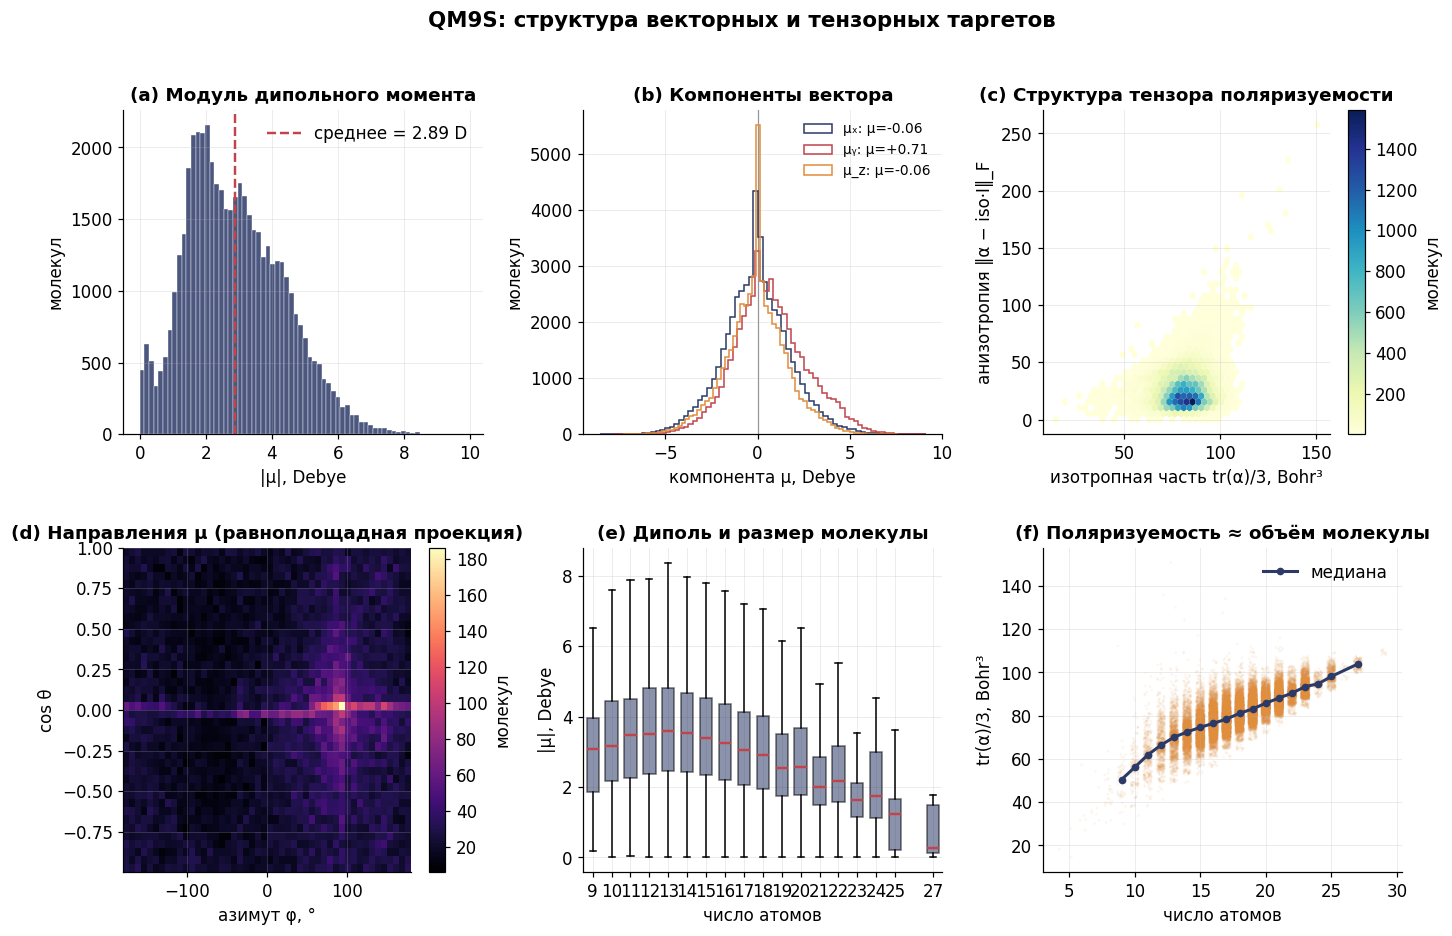

In [23]:
fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.28)

# ---------------------------------------------------- (a) распределение |mu|
ax = fig.add_subplot(gs[0, 0])
ax.hist(mu_norms, bins=70, color=C['true'], alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(mu_norms.mean(), color=C['pred'], ls='--', lw=1.6,
           label=f"среднее = {mu_norms.mean():.2f} D")
ax.set_xlabel('|μ|, Debye'); ax.set_ylabel('молекул')
ax.set_title('(a) Модуль дипольного момента'); ax.legend()

# ---------------------------------------- (b) компоненты mu: три распределения
ax = fig.add_subplot(gs[0, 1])
for i, (lbl, col) in enumerate(zip(['μₓ', 'μᵧ', 'μ_z'],
                                   [C['true'], C['pred'], C['accent']])):
    ax.hist(mu_vecs[:, i], bins=70, histtype='step', lw=1.8, color=col,
            label=f"{lbl}: μ={mu_vecs[:, i].mean():+.2f}")
ax.axvline(0, color=C['neutral'], lw=0.8, zorder=0)
ax.set_xlabel('компонента μ, Debye'); ax.set_ylabel('молекул')
ax.set_title('(b) Компоненты вектора'); ax.legend(fontsize=9)

# --------------------------------- (c) изотропная vs анизотропная часть alpha
ax = fig.add_subplot(gs[0, 2])
hb = ax.hexbin(alpha_iso, alpha_ani, gridsize=45, cmap='YlGnBu', mincnt=1, linewidths=0)
ax.set_xlabel('изотропная часть tr(α)/3, Bohr³')
ax.set_ylabel('анизотропия ‖α − iso·I‖_F')
ax.set_title('(c) Структура тензора поляризуемости')
plt.colorbar(hb, ax=ax, label='молекул')

# ------------------------------- (d) направления mu на сфере: широта/долгота
ax = fig.add_subplot(gs[1, 0])
unit = mu_vecs / np.clip(mu_norms[:, None], 1e-9, None)
theta = np.degrees(np.arccos(np.clip(unit[:, 2], -1, 1)))     # полярный угол
phi   = np.degrees(np.arctan2(unit[:, 1], unit[:, 0]))        # азимут
h = ax.hist2d(phi, np.cos(np.radians(theta)), bins=[48, 40],
              cmap='magma', cmin=1)
ax.set_xlabel('азимут φ, °'); ax.set_ylabel('cos θ')
ax.set_title('(d) Направления μ (равноплощадная проекция)')
plt.colorbar(h[3], ax=ax, label='молекул')

# ------------------------------------------- (e) |mu| в зависимости от размера
ax = fig.add_subplot(gs[1, 1])
sizes = np.arange(n_atoms.min(), n_atoms.max() + 1)
data  = [mu_norms[n_atoms == s] for s in sizes]
keep  = [i for i, d in enumerate(data) if len(d) > 30]
bp = ax.boxplot([data[i] for i in keep], positions=sizes[keep], widths=0.65,
                patch_artist=True, showfliers=False,
                medianprops=dict(color=C['pred'], lw=1.6))
for patch in bp['boxes']:
    patch.set_facecolor(C['true']); patch.set_alpha(0.55)
ax.set_xlabel('число атомов'); ax.set_ylabel('|μ|, Debye')
ax.set_title('(e) Диполь и размер молекулы')

# ------------------------------------- (f) изотропная alpha vs число атомов
ax = fig.add_subplot(gs[1, 2])
ax.scatter(n_atoms + np.random.uniform(-.3, .3, len(n_atoms)), alpha_iso,
           s=3, alpha=0.08, color=C['accent'], edgecolors='none')
med = [np.median(alpha_iso[n_atoms == s]) for s in sizes[keep]]
ax.plot(sizes[keep], med, color=C['true'], lw=2, marker='o', ms=4,
        label='медиана')
ax.set_xlabel('число атомов'); ax.set_ylabel('tr(α)/3, Bohr³')
ax.set_title('(f) Поляризуемость ≈ объём молекулы'); ax.legend()

fig.suptitle('QM9S: структура векторных и тензорных таргетов',
             fontsize=14, fontweight='semibold', y=0.98)
plt.show()

### 3.1. Что мы вообще предсказываем

Дипольный вектор и тензор поляризуемости — не абстрактные наборы чисел, а геометрические объекты,
жёстко привязанные к структуре молекулы. Диполь рисуется стрелкой из центра масс, поляризуемость —
эллипсоидом, полуоси которого равны собственным значениям $\alpha$, а направления — собственным
векторам. Вытянутый эллипсоид означает, что молекула легче поляризуется вдоль одной оси.

При повороте молекулы стрелка и эллипсоид обязаны поворачиваться вместе с ней. Именно это
требование мы и закладываем в архитектуру.

Единый радиус кадра: 3.84 Å


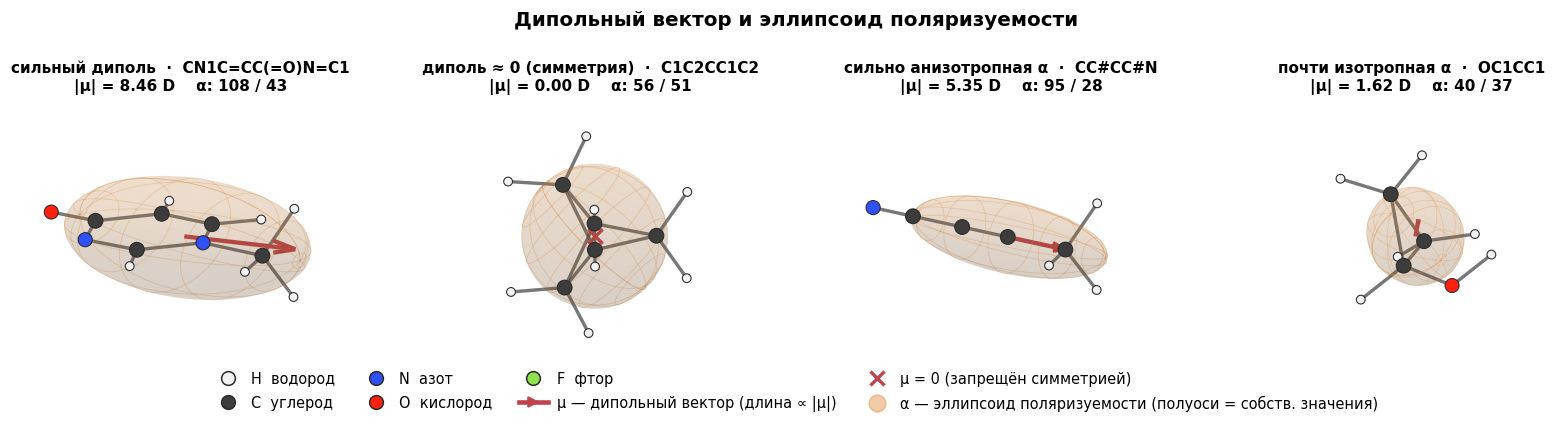

In [24]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.lines import Line2D

COV_RADIUS = {1: 0.31, 6: 0.76, 7: 0.71, 8: 0.66, 9: 0.57}   # Å


def find_bonds(z, pos, tol=1.3):
    """Связь есть, если расстояние меньше суммы ковалентных радиусов * tol."""
    bonds = []
    for i in range(len(z)):
        for j in range(i + 1, len(z)):
            d = np.linalg.norm(pos[i] - pos[j])
            r = COV_RADIUS.get(int(z[i]), 0.7) + COV_RADIUS.get(int(z[j]), 0.7)
            if d < r * tol:
                bonds.append((i, j))
    return bonds


def draw_molecule(ax, mol, show_dipole=True, show_ellipsoid=True,
                  mu_override=None, mu_scale=0.55, ellip_scale=0.030,
                  title=None, ellip_color=None, atom_colors=None,
                  atom_size_scale=0.55, fixed_r=None, zoom=1.0):
    """Молекула + вектор диполя (красная стрелка) + эллипсоид поляризуемости.

    mu_override — нарисовать чужой вектор вместо истинного (для предсказаний)
    atom_colors — задать цвета атомов вручную (для раскраски по зарядам)
    ellip_color — цвет эллипсоида (истина vs предсказание)
    fixed_r     — единый радиус кадра для всех панелей (сопоставимость размеров)
    zoom        — приближение внутри кадра; 3D-оси matplotlib оставляют много
                  пустого места, поэтому рабочие значения ~2.0-3.0
    """
    z, pos = mol['z'], mol['pos'].astype(float)
    p = pos - pos.mean(0)                      # центрируем

    # --- связи
    for i, j in find_bonds(z, pos):
        ax.plot(*zip(p[i], p[j]), color='#4A4A4A', lw=2.2, alpha=0.75, zorder=2)

    # --- атомы
    colors, sizes = atom_style(z, atom_size_scale)
    if atom_colors is not None:
        colors = atom_colors
    ax.scatter(p[:, 0], p[:, 1], p[:, 2], c=colors, s=sizes,
               edgecolors='#2A2A2A', linewidths=0.7, depthshade=False, zorder=3)

    reach = np.abs(p).max()

    # --- эллипсоид поляризуемости: полуоси = собственные значения α
    if show_ellipsoid:
        ev, evec = np.linalg.eigh(mol['alpha'])
        u = np.linspace(0, 2 * np.pi, 48)
        v = np.linspace(0, np.pi, 26)
        sph = np.stack([np.outer(np.cos(u), np.sin(v)),
                        np.outer(np.sin(u), np.sin(v)),
                        np.outer(np.ones_like(u), np.cos(v))])
        L = np.clip(ev, 1e-3, None) * ellip_scale
        ell = np.einsum('ij,jkl->ikl', evec, sph * L[:, None, None])
        col = ellip_color or C['accent']
        ax.plot_surface(*ell, color=col, alpha=0.13, linewidth=0,
                        antialiased=True, zorder=0)
        ax.plot_wireframe(*ell, color=col, alpha=0.30, linewidth=0.5,
                          rstride=6, cstride=4, zorder=1)
        reach = max(reach, np.abs(ell).max())

    # --- вектор диполя
    if show_dipole:
        mu = mol['mu'] if mu_override is None else mu_override
        if np.linalg.norm(mu) > 0.05:
            v = np.asarray(mu, dtype=float) * mu_scale
            ax.quiver(0, 0, 0, *v, color=C['pred'], lw=2.8,
                      arrow_length_ratio=0.20, zorder=5)
            reach = max(reach, np.abs(v).max())
        else:
            ax.scatter([0], [0], [0], marker='x', s=90, c=C['pred'],
                       linewidths=2.2, zorder=6)

    # --- кадр: куб без осей
    r = fixed_r if fixed_r is not None else reach * 1.12
    ax.set_xlim(-r, r); ax.set_ylim(-r, r); ax.set_zlim(-r, r)
    ax.set_box_aspect((1, 1, 1), zoom=zoom)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=10, pad=-2)


def atom_legend(fig, y=0.0):
    """Легенда: элементы + смысл графических элементов."""
    ATOM_INFO = {1: 'H  водород', 6: 'C  углерод', 7: 'N  азот',
                 8: 'O  кислород', 9: 'F  фтор'}
    handles = [Line2D([], [], marker='o', ls='', markersize=9,
                      markerfacecolor=CPK_COLOR[z], markeredgecolor='#2A2A2A',
                      label=ATOM_INFO[z]) for z in (1, 6, 7, 8, 9)]
    handles += [
        Line2D([], [], color=C['pred'], lw=3, marker='>', markersize=7,
               label='μ — дипольный вектор (длина ∝ |μ|)'),
        Line2D([], [], marker='x', ls='', markersize=9, color=C['pred'],
               markeredgewidth=2.2, label='μ = 0 (запрещён симметрией)'),
        Line2D([], [], marker='o', ls='', markersize=11, alpha=0.45,
               markerfacecolor=C['accent'], markeredgecolor=C['accent'],
               label='α — эллипсоид поляризуемости (полуоси = собств. значения)'),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False,
               bbox_to_anchor=(0.5, y), fontsize=9.5,
               handletextpad=0.6, columnspacing=1.8, labelspacing=0.6)


# ---------------------------------------------- автоматический выбор примеров
eigs_all   = np.linalg.eigvalsh(alphas)
anis_ratio = eigs_all[:, 2] / np.clip(eigs_all[:, 0], 1e-6, None)
mask_mid   = (n_atoms >= 8) & (n_atoms <= 14)     # размер, при котором картинка читается


def first_where(cond, msg):
    idx = np.where(mask_mid & cond)[0]
    if len(idx) == 0:
        raise ValueError(msg)
    return int(idx[0])


picks = [
    (first_where(mu_norms > np.quantile(mu_norms, 0.999), 'нет молекул с большим μ'),
     'сильный диполь'),
    (first_where(mu_norms < 0.05, 'нет неполярных молекул'),
     'диполь ≈ 0 (симметрия)'),
    (first_where(anis_ratio > np.quantile(anis_ratio, 0.995), 'нет анизотропных α'),
     'сильно анизотропная α'),
    (first_where(anis_ratio < np.quantile(anis_ratio, 0.02), 'нет изотропных α'),
     'почти изотропная α'),
]

MU_SCALE, ELLIP_SCALE, ZOOM = 0.28, 0.026, 2.2
# Единый радиус кадра, чтобы размеры были сопоставимы между панелями
common_r = 1.05 * max(
    max(np.abs(molecules[i]['pos'] - molecules[i]['pos'].mean(0)).max(),
        np.linalg.eigvalsh(molecules[i]['alpha']).max() * ELLIP_SCALE,
        np.linalg.norm(molecules[i]['mu']) * MU_SCALE)
    for i, _ in picks)
print(f"Единый радиус кадра: {common_r:.2f} Å")

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), subplot_kw={'projection': '3d'})
for ax, (idx, label) in zip(axes, picks):
    m  = molecules[idx]
    ev = np.linalg.eigvalsh(m['alpha'])
    draw_molecule(ax, m, mu_scale=MU_SCALE, ellip_scale=ELLIP_SCALE,
                  fixed_r=common_r, zoom=ZOOM,
                  title=(f"{label}  ·  {m['smiles']}\n"
                         f"|μ| = {np.linalg.norm(m['mu']):.2f} D    "
                         f"α: {ev[2]:.0f} / {ev[0]:.0f}"))
    ax.view_init(elev=16, azim=40)

atom_legend(fig, y=0.0)
fig.suptitle('Дипольный вектор и эллипсоид поляризуемости',
             fontsize=13, fontweight='semibold', y=0.99)
fig.subplots_adjust(left=0.0, right=1.0, top=0.79, bottom=0.09, wspace=-0.02)
plt.show()

**Как читать эти панели.**

Красная стрелка — дипольный момент, отложенный от центра масс; её длина пропорциональна
$|\boldsymbol{\mu}|$ в едином для всех четырёх панелей масштабе. Янтарный эллипсоид —
поляризуемость: его полуоси равны собственным значениям $\alpha$, а ориентация задана
собственными векторами, так что вытянутость эллипсоида показывает, вдоль какого направления
молекула поляризуется легче.

Ракурс на всех панелях одинаковый (elev = 16°, azim = 40°) — молекулы намеренно не
разворачиваются под удобный вид, потому что вся суть задачи в том, что $\boldsymbol{\mu}$ и
$\alpha$ жёстко привязаны к геометрии, а не к осям экрана. Побочный эффект: у **циклопропанола
(панель 4)** диполь направлен почти на наблюдателя, поэтому в проекции стрелка схлопывается
в короткий обрубок — вектор там есть и равен 1.62 D, просто он смотрит «из экрана».

**Панель 2 — контрольная.** У бициклопентана `C1C2CC1C2` нет гетероатомов, а геометрия
симметрична, поэтому $\boldsymbol{\mu} = 0$ **точно**, а не приближённо: вклады связей взаимно
сокращаются. Вместо стрелки нарисован крестик. Тензор поляризуемости при этом почти изотропен
(56 / 51) — молекула одинаково поляризуется во всех направлениях.

Этот контраст задаёт планку для модели: предсказывать $\boldsymbol{\mu}$ — значит воспроизводить
не только величину, но и **направление**, а для симметричных молекул — уметь занулять его точно.
Модель, предсказывающая три числа обычной линейной головой, ни того, ни другого не гарантирует.

## 4. Топологические признаки

Строим фильтрацию Виеториса–Рипса по облаку атомов: вокруг каждого атома растёт шар радиуса
$\varepsilon$, симплекс добавляется, когда все его вершины попарно сблизились. Отслеживаем, как
рождаются и умирают связные компоненты ($H_0$) и одномерные циклы ($H_1$).

Содержательно: $H_0$-персистентности кодируют длины связей и расстояния между фрагментами,
$H_1$ — кольца в молекуле.

Важно сразу зафиксировать свойство, к которому мы вернёмся при анализе результатов: фильтрация
строится по **попарным евклидовым расстояниям**, а они не меняются ни при вращении, ни при
отражении. Значит все признаки ниже **инвариантны относительно всей группы $O(3)$** — это будет
иметь прямые последствия для векторного таргета.

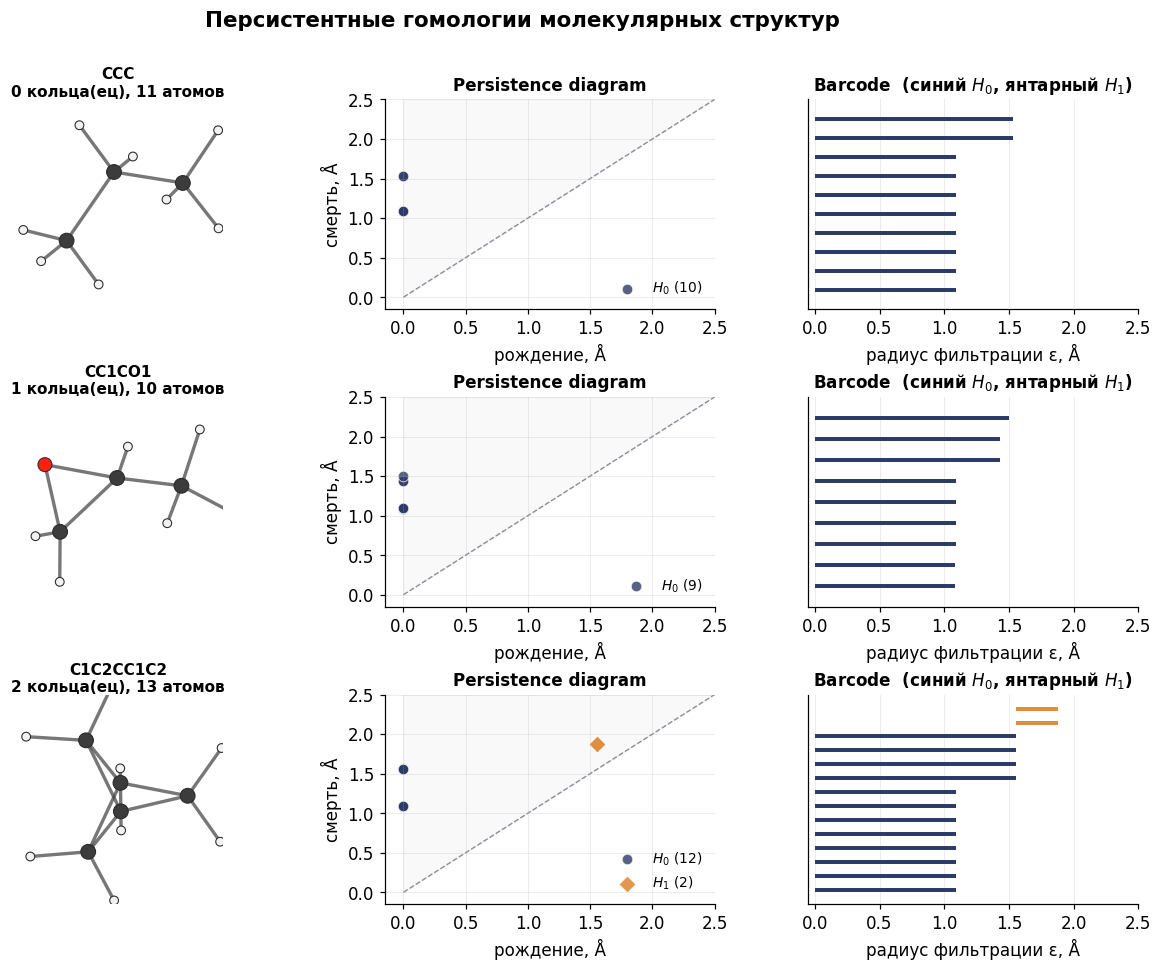

Соответствие числа H₁-циклов числу колец в SMILES:
  CCC                    колец=0  H₁-циклов=0
  CC1CO1                 колец=1  H₁-циклов=0
  C1C2CC1C2              колец=2  H₁-циклов=2


In [25]:
import gudhi as gd

TDA_NAMES = ['h0_count', 'h0_sum', 'h0_max', 'h0_mean', 'h0_std',
             'h1_count', 'h1_sum', 'h1_max', 'h1_mean', 'h1_birth_mean']


def tda_diagrams(pos, max_edge=None):
    """Персистентные диаграммы H0 и H1 для облака атомов.
    Бесконечный бар H0 (вся молекула как одна компонента) отбрасывается."""
    max_edge = max_edge or CFG['tda_max_edge']
    st = gd.RipsComplex(points=np.asarray(pos, dtype=np.float64),
                        max_edge_length=max_edge).create_simplex_tree(max_dimension=2)
    st.compute_persistence()
    h0 = st.persistence_intervals_in_dimension(0)
    h1 = st.persistence_intervals_in_dimension(1)
    h0 = h0[np.isfinite(h0[:, 1])] if len(h0) else np.zeros((0, 2))
    h1 = h1[np.isfinite(h1[:, 1])] if len(h1) else np.zeros((0, 2))
    return h0, h1


def tda_features(pos, max_edge=None):
    """10 сводных статистик персистентных диаграмм."""
    h0, h1 = tda_diagrams(pos, max_edge)
    p0 = h0[:, 1] - h0[:, 0] if len(h0) else np.array([0.0])
    p1 = h1[:, 1] - h1[:, 0] if len(h1) else np.array([0.0])
    return np.array([
        len(h0), p0.sum(), p0.max(), p0.mean(), p0.std(),
        len(h1), p1.sum(), p1.max(), p1.mean(),
        h1[:, 0].mean() if len(h1) else 0.0,
    ], dtype=np.float32)


# ------------------------------------------------- выбираем молекулы с кольцами
demo_idx = [int(np.where((n_rings == k) & (n_atoms >= 9) & (n_atoms <= 14))[0][0])
            for k in (0, 1, 2)]

fig = plt.figure(figsize=(14, 9.5))
gs = fig.add_gridspec(3, 3, width_ratios=[1.05, 1, 1], hspace=0.42, wspace=0.28)

for row, idx in enumerate(demo_idx):
    m = molecules[idx]
    h0, h1 = tda_diagrams(m['pos'])

    # --- структура
    ax = fig.add_subplot(gs[row, 0], projection='3d')
    draw_molecule(ax, m, show_dipole=False, show_ellipsoid=False, zoom=2.0,
                  title=f"{m['smiles']}\n{n_rings[idx]} кольца(ец), {m['n_atoms']} атомов")
    ax.view_init(elev=16, azim=40)

    # --- persistence diagram
    ax = fig.add_subplot(gs[row, 1])
    lim = CFG['tda_max_edge']
    ax.plot([0, lim], [0, lim], color=C['neutral'], lw=0.9, ls='--', zorder=0)
    ax.fill_between([0, lim], [0, lim], [lim, lim], color=C['neutral'], alpha=0.05)
    if len(h0):
        ax.scatter(h0[:, 0], h0[:, 1], s=48, color=C['true'], alpha=0.8,
                   label=f'$H_0$ ({len(h0)})', edgecolors='white', linewidths=0.6)
    if len(h1):
        ax.scatter(h1[:, 0], h1[:, 1], s=62, color=C['accent'], alpha=0.9, marker='D',
                   label=f'$H_1$ ({len(h1)})', edgecolors='white', linewidths=0.6)
    ax.set_xlim(-0.15, lim); ax.set_ylim(-0.15, lim)
    ax.set_xlabel('рождение, Å'); ax.set_ylabel('смерть, Å')
    ax.set_title('Persistence diagram', fontsize=11)
    ax.legend(fontsize=9, loc='lower right')

    # --- barcode
    ax = fig.add_subplot(gs[row, 2])
    bars = [(b, d, C['true']) for b, d in h0] + [(b, d, C['accent']) for b, d in h1]
    bars.sort(key=lambda t: (t[2] != C['true'], t[0]))
    for k, (b, d, col) in enumerate(bars):
        ax.plot([b, d], [k, k], color=col, lw=2.6, solid_capstyle='butt')
    ax.set_xlim(-0.05, lim); ax.set_ylim(-1, max(len(bars), 1))
    ax.set_xlabel('радиус фильтрации ε, Å'); ax.set_yticks([])
    ax.set_title('Barcode  (синий $H_0$, янтарный $H_1$)', fontsize=11)

fig.suptitle('Персистентные гомологии молекулярных структур',
             fontsize=14, fontweight='semibold', y=0.965)
plt.show()

# ------------------------------------------------------------ проверка H1 vs кольца
print("Соответствие числа H₁-циклов числу колец в SMILES:")
for idx in demo_idx:
    _, h1 = tda_diagrams(molecules[idx]['pos'])
    print(f"  {molecules[idx]['smiles']:<22} колец={n_rings[idx]}  "
          f"H₁-циклов={len(h1)}")

### 4.1. Расчёт признаков для датасета

Фильтрация Рипса строится для каждой молекулы отдельно и стоит заметного времени, поэтому
результат кэшируется на диск: повторный запуск ячейки читает готовый массив.

In [26]:
from concurrent.futures import ProcessPoolExecutor

TDA_CACHE = f"{CACHE_DIR}/tda_{CFG['n_molecules']}_{CFG['tda_max_edge']}.npz"

if os.path.exists(TDA_CACHE):
    tda_all = np.load(TDA_CACHE)['tda']
    print(f"Загружено из кэша: {TDA_CACHE}  →  {tda_all.shape}")
else:
    # оценка времени на выборке
    t0 = time.time()
    for m in molecules[:200]:
        tda_features(m['pos'])
    per_mol = (time.time() - t0) / 200
    n_cpu = os.cpu_count() or 2
    print(f"~{per_mol * 1000:.1f} мс/молекулу, ядер: {n_cpu}, "
          f"оценка: ~{per_mol * len(molecules) / max(n_cpu - 1, 1) / 60:.1f} мин")

    positions = [m['pos'] for m in molecules]
    with ProcessPoolExecutor(max_workers=max(n_cpu - 1, 1)) as ex:
        tda_all = np.stack(list(tqdm(ex.map(tda_features, positions, chunksize=200),
                                     total=len(positions), desc='TDA')))

    np.savez_compressed(TDA_CACHE, tda=tda_all)
    print(f"Сохранено в {TDA_CACHE}")

assert tda_all.shape == (len(molecules), len(TDA_NAMES)), tda_all.shape
assert np.all(np.isfinite(tda_all)), 'в TDA-признаках есть NaN/inf'

# ------------------------------------------------------------------ сводка
tda_df = pd.DataFrame(tda_all, columns=TDA_NAMES)
print(f"\nПризнаков: {tda_all.shape[1]}, молекул: {tda_all.shape[0]:,}\n")
display(tda_df.describe().T[['mean', 'std', 'min', '50%', 'max']].round(3))

# ------------------------------------------------ вырожденные признаки?
print("\nДиагностика признаков:")
for j, name in enumerate(TDA_NAMES):
    col = tda_all[:, j]
    uniq = len(np.unique(np.round(col, 4)))
    flag = ''
    if col.std() < 1e-6:
        flag = '  <-- КОНСТАНТА, бесполезен'
    elif uniq < 10:
        flag = f'  <-- почти дискретен ({uniq} значений)'
    print(f"  {name:<16} std={col.std():7.3f}  уникальных={uniq:<6}{flag}")

# ------------------------------- сколько молекул вообще имеют H1-циклы?
frac_h1 = (tda_all[:, TDA_NAMES.index('h1_count')] > 0).mean()
print(f"\nДоля молекул с хотя бы одним H₁-циклом: {100 * frac_h1:.1f}%")

~0.1 мс/молекулу, ядер: 2, оценка: ~0.1 мин


TDA:   0%|          | 0/50000 [00:00<?, ?it/s]

Сохранено в ./emt_cache/tda_50000_2.5.npz

Признаков: 10, молекул: 50,000



,mean,std,min,50%,max
h0_count,17.007,2.948,3.000,17.000,28.000
h0_sum,21.161,3.597,3.324,21.197,34.218
h0_max,1.526,0.034,1.090,1.533,2.339
h0_mean,1.245,0.017,1.090,1.244,1.369
h0_std,0.189,0.018,0.000,0.192,0.364
h1_count,1.210,0.933,0.000,1.000,8.000
h1_sum,0.716,0.526,0.000,0.760,3.301
h1_max,0.538,0.335,0.000,0.609,1.059
h1_mean,0.495,0.319,0.000,0.569,1.029
h1_birth_mean,1.263,0.678,0.000,1.540,2.497



Диагностика признаков:
  h0_count         std=  2.948  уникальных=25    
  h0_sum           std=  3.597  уникальных=38769 
  h0_max           std=  0.034  уникальных=2186  
  h0_mean          std=  0.017  уникальных=1122  
  h0_std           std=  0.018  уникальных=1184  
  h1_count         std=  0.933  уникальных=9       <-- почти дискретен (9 значений)
  h1_sum           std=  0.526  уникальных=13510 
  h1_max           std=  0.335  уникальных=7701  
  h1_mean          std=  0.319  уникальных=8675  
  h1_birth_mean    std=  0.678  уникальных=6562  

Доля молекул с хотя бы одним H₁-циклом: 78.9%


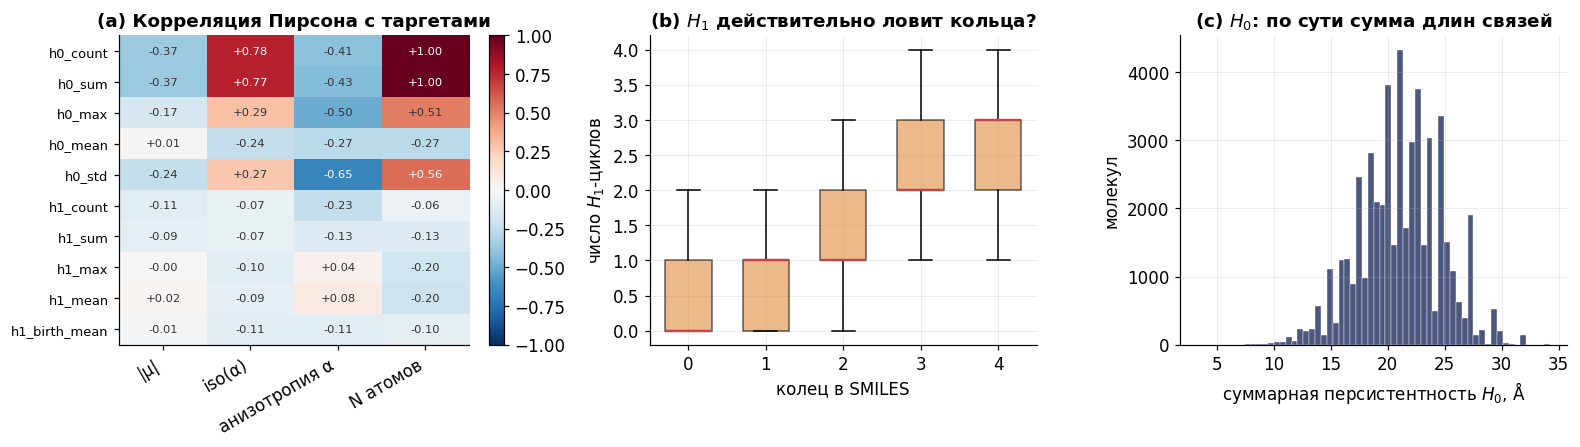

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))

# (a) корреляции TDA-признаков с таргетами
targets = pd.DataFrame({'|μ|': mu_norms, 'iso(α)': alpha_iso,
                        'анизотропия α': alpha_ani, 'N атомов': n_atoms})
corr = np.array([[np.corrcoef(tda_all[:, j], targets[t])[0, 1]
                  for t in targets.columns] for j in range(len(TDA_NAMES))])

ax = axes[0]
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(targets.columns)))
ax.set_xticklabels(targets.columns, rotation=30, ha='right')
ax.set_yticks(range(len(TDA_NAMES))); ax.set_yticklabels(TDA_NAMES, fontsize=8.5)
for i in range(corr.shape[0]):
    for k in range(corr.shape[1]):
        ax.text(k, i, f'{corr[i, k]:+.2f}', ha='center', va='center', fontsize=7.5,
                color='white' if abs(corr[i, k]) > 0.55 else '#333')
ax.set_title('(a) Корреляция Пирсона с таргетами'); ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.046)

# (b) число H1-циклов vs число колец в SMILES
ax = axes[1]
h1c = tda_all[:, TDA_NAMES.index('h1_count')]
rings_max = min(n_rings.max(), 4)
data = [h1c[n_rings == k] for k in range(rings_max + 1)]
pos_ = [k for k in range(rings_max + 1) if len(data[k]) > 20]
bp = ax.boxplot([data[k] for k in pos_], positions=pos_, widths=0.6,
                patch_artist=True, showfliers=False,
                medianprops=dict(color=C['pred'], lw=1.6))
for p in bp['boxes']:
    p.set_facecolor(C['accent']); p.set_alpha(0.6)
ax.set_xlabel('колец в SMILES'); ax.set_ylabel('число $H_1$-циклов')
ax.set_title('(b) $H_1$ действительно ловит кольца?')

# (c) распределение суммарной персистентности H0
ax = axes[2]
ax.hist(tda_all[:, TDA_NAMES.index('h0_sum')], bins=60, color=C['true'],
        alpha=0.85, edgecolor='white', linewidth=0.3)
ax.set_xlabel('суммарная персистентность $H_0$, Å'); ax.set_ylabel('молекул')
ax.set_title('(c) $H_0$: по сути сумма длин связей')

plt.tight_layout(); plt.show()

### 4.2. Подбор масштаба фильтрации

Порог Виеториса–Рипса выбирается по физическому критерию: число $H_1$-циклов должно
коррелировать с числом колец в молекуле, а не с её размером.

In [28]:
def h1_vs_rings(max_edge, n_probe=3000):
    """Как разделяются молекулы по числу колец при заданном пороге фильтрации."""
    idx = np.random.default_rng(0).choice(len(molecules), n_probe, replace=False)
    h1c = np.array([len(tda_diagrams(molecules[i]['pos'], max_edge)[1]) for i in idx])
    r = n_rings[idx]
    rows = []
    for k in range(0, min(r.max(), 3) + 1):
        sel = h1c[r == k]
        if len(sel) > 20:
            rows.append((k, len(sel), sel.mean(), np.median(sel), (sel == 0).mean()))
    return h1c, r, rows


print(f"{'ε_max':>6} | {'колец':>5} {'молекул':>8} {'ср. H₁':>7} {'медиана':>8} "
      f"{'доля H₁=0':>10}")
print('─' * 70)
results = {}
for me in [2.0, 2.5, 3.0, 4.0, 5.0]:
    h1c, r, rows = h1_vs_rings(me)
    results[me] = (h1c, r)
    for k, n, mean, med, zero in rows:
        print(f"{me:>6.1f} | {k:>5} {n:>8} {mean:>7.2f} {med:>8.0f} {zero:>9.0%}")
    # ключевой критерий: корреляция с кольцами против корреляции с размером
    sz = n_atoms[np.random.default_rng(0).choice(len(molecules), len(h1c), replace=False)]
    print(f"{'':>6} | corr(H₁, кольца) = {np.corrcoef(h1c, r)[0, 1]:+.3f}   "
          f"corr(H₁, N атомов) = {np.corrcoef(h1c, sz)[0, 1]:+.3f}")
    print('─' * 70)

 ε_max | колец  молекул  ср. H₁  медиана  доля H₁=0
──────────────────────────────────────────────────────────────────────
   2.0 |     0      285    0.00        0      100%
   2.0 |     1     1153    0.00        0      100%
   2.0 |     2     1002    0.13        0       93%
   2.0 |     3      461    0.38        0       80%
       | corr(H₁, кольца) = +0.288   corr(H₁, N атомов) = +0.009
──────────────────────────────────────────────────────────────────────
   2.5 |     0      285    0.27        0       76%
   2.5 |     1     1153    0.84        1       24%
   2.5 |     2     1002    1.34        1       12%
   2.5 |     3      461    2.07        2        2%
       | corr(H₁, кольца) = +0.624   corr(H₁, N атомов) = -0.047
──────────────────────────────────────────────────────────────────────
   3.0 |     0      285    1.04        1       43%
   3.0 |     1     1153    1.48        1        8%
   3.0 |     2     1002    2.13        2        1%
   3.0 |     3      461    2.70        3    

## 5. Разбиение выборки

Три части вместо двух: валидационная нужна для честного выбора числа эпох и порогов, чтобы
тестовая выборка оставалась нетронутой до финального замера. В исходной версии проекта
валидации не было, и число эпох подбиралось фактически по тесту.

Разбиение фиксировано сидом и переиспользуется всеми моделями — RF, FCNN и SchNet видят
ровно одни и те же молекулы, иначе сравнение метрик теряет смысл.

In [29]:
set_seed(42)
n_total = len(molecules)
perm = np.random.permutation(n_total)

f_tr, f_va, f_te = CFG['split']
n_tr = int(f_tr * n_total)
n_va = int(f_va * n_total)

idx_train = perm[:n_tr]
idx_val   = perm[n_tr:n_tr + n_va]
idx_test  = perm[n_tr + n_va:]

SPLITS = {'train': idx_train, 'val': idx_val, 'test': idx_test}

print(f"{'выборка':<8} {'молекул':>9} {'доля':>7}   "
      f"{'ср. |μ|':>9} {'ср. iso(α)':>11} {'ср. N атомов':>13}")
print('─' * 70)
for name, idx in SPLITS.items():
    print(f"{name:<8} {len(idx):>9,} {len(idx) / n_total:>6.1%}   "
          f"{mu_norms[idx].mean():>9.3f} {alpha_iso[idx].mean():>11.2f} "
          f"{n_atoms[idx].mean():>13.1f}")

assert len(set(idx_train) & set(idx_test)) == 0, 'пересечение train/test'
assert len(set(idx_val) & set(idx_test)) == 0, 'пересечение val/test'
assert len(idx_train) + len(idx_val) + len(idx_test) == n_total
print("\n✓ Выборки не пересекаются")

# --------------------------------------- статистики для нормировки (только train!)
MU_MEAN  = mu_vecs[idx_train].mean(0)
MU_STD   = mu_vecs[idx_train].std(0)
ALPHA_STD = alphas[idx_train].reshape(-1, 9).std(0).reshape(3, 3)
ALPHA_STD_SCALAR = float(alphas[idx_train].std())

print(f"\nСтатистики нормировки (по train):")
print(f"  μ: mean = [{MU_MEAN[0]:+.3f}, {MU_MEAN[1]:+.3f}, {MU_MEAN[2]:+.3f}], "
      f"std = [{MU_STD[0]:.3f}, {MU_STD[1]:.3f}, {MU_STD[2]:.3f}]")
print(f"  α: std (скаляр) = {ALPHA_STD_SCALAR:.3f} Bohr³")


выборка    молекул    доля     ср. |μ|  ср. iso(α)  ср. N атомов
──────────────────────────────────────────────────────────────────────
train       35,000  70.0%       2.897       81.50          18.0
val          5,000  10.0%       2.892       81.52          18.0
test        10,000  20.0%       2.888       81.51          18.0

✓ Выборки не пересекаются

Статистики нормировки (по train):
  μ: mean = [-0.058, +0.704, -0.056], std = [1.823, 1.976, 1.683]
  α: std (скаляр) = 39.746 Bohr³


**Почему $\boldsymbol{\mu}$ не нормируется покомпонентно.**

Стандартная практика ML требует стандартизовать таргет, но для векторной величины это ломает
ровно то свойство, ради которого всё строится. Вычитание вектора `MU_MEAN` нарушило бы
эквивариантность: при повороте молекулы сдвиг остался бы прежним, то есть
$R(\boldsymbol{\mu} - \mathbf{c}) \neq R\boldsymbol{\mu} - \mathbf{c}$.

Статистики выше приведены только как справочные. Для $\alpha$ используется **скалярная**
нормировка лосса, которая эквивариантность сохраняет: умножение тензора на число коммутирует
с $R\,\alpha\,R^{\top}$.

## 6. Бейзлайны

Нижняя планка: градиентный лес на ручных геометрических признаках. Здесь важен принципиальный
момент, который задаёт рамку всему проекту.

Все признаки ниже — **инвариантны** относительно $O(3)$: радиус инерции, моменты инерции,
статистики межатомных расстояний, состав по элементам, топологические признаки. Ни один из них
не меняется при повороте молекулы. Из этого следует жёсткое ограничение: **модель на инвариантных
признаках принципиально не способна предсказать направление $\boldsymbol{\mu}$** — она может
предсказать только скалярную величину $|\boldsymbol{\mu}|$.

Это не недостаток реализации, а теорема: если $f(\mathbf{x}) = f(R\mathbf{x})$ для всех $R$, то
$f$ не может равняться $\boldsymbol{\mu}(\mathbf{x})$, которое обязано меняться как
$R\boldsymbol{\mu}$. Поэтому RF обучается предсказывать $|\boldsymbol{\mu}|$ и
$\mathrm{tr}(\alpha)/3$ — инвариантные редукции таргетов.

In [30]:
from sklearn.ensemble import RandomForestRegressor
from scipy.spatial.distance import pdist


def simple_features(mol):
    """Инвариантные геометрические признаки (не меняются при вращении/отражении)."""
    z, pos = mol['z'], mol['pos'].astype(np.float64)
    p = pos - pos.mean(0)
    d = pdist(p) if len(p) > 1 else np.array([0.0])

    # тензор инерции (единичные массы) -> собственные значения инвариантны
    I = np.eye(3) * (p ** 2).sum() - p.T @ p
    inertia = np.linalg.eigvalsh(I)

    counts = [int((z == e).sum()) for e in (1, 6, 7, 8, 9)]
    heavy = len(z) - counts[0]

    return np.array([
        len(z), heavy, *counts,
        np.sqrt((p ** 2).sum(1).mean()),            # радиус инерции
        d.mean(), d.std(), d.min(), d.max(),
        np.percentile(d, 25), np.percentile(d, 75),
        *inertia,
        inertia[2] / max(inertia[0], 1e-6),          # асферичность
    ], dtype=np.float32)


SIMPLE_NAMES = ['n_atoms', 'n_heavy', 'nH', 'nC', 'nN', 'nO', 'nF',
                'r_gyr', 'd_mean', 'd_std', 'd_min', 'd_max', 'd_q25', 'd_q75',
                'I1', 'I2', 'I3', 'asphericity']

RF_CACHE = f'{CACHE_DIR}/rf_results.pkl'

# --- часть 1: признаки. Считаем, только если их ещё нет в памяти
if 'X_simple' not in globals():
    print('Расчёт простых признаков...')
    X_simple = np.stack([simple_features(m) for m in tqdm(molecules)])
X_both = np.hstack([X_simple, tda_all])
print(f"простые: {X_simple.shape},  простые+TDA: {X_both.shape}")

y_mu_norm = mu_norms
y_a_iso   = alpha_iso

# --- часть 2: леса. Читаем с диска, если файл есть
if os.path.exists(RF_CACHE):
    with open(RF_CACHE, 'rb') as f:
        rf_results = pickle.load(f)
    print('RF-результаты загружены из кэша')
else:
    rf_results = {}
    for feat_name, X in [('простые', X_simple), ('простые + TDA', X_both)]:
        row = {}
        for tgt_name, y in [('|μ|, D', y_mu_norm), ('iso(α), Bohr³', y_a_iso)]:
            rf = RandomForestRegressor(n_estimators=200, max_depth=None,
                                       n_jobs=-1, random_state=0)
            rf.fit(X[idx_train], y[idx_train])
            pred_va = rf.predict(X[idx_val])
            pred_te = rf.predict(X[idx_test])
            row[tgt_name] = {
                'MAE_val':  np.abs(pred_va - y[idx_val]).mean(),
                'MAE_test': np.abs(pred_te - y[idx_test]).mean(),
                'R2_test':  1 - ((pred_te - y[idx_test]) ** 2).sum() /
                                ((y[idx_test] - y[idx_test].mean()) ** 2).sum(),
                'importances': rf.feature_importances_,
            }
        rf_results[feat_name] = row
    with open(RF_CACHE, 'wb') as f:
        pickle.dump(rf_results, f)
    print('RF обучены и сохранены в кэш')

# --- печать таблицы: выполняется ВСЕГДА, вне if/else
print(f"\n{'признаки':<16} {'таргет':<16} {'MAE val':>9} {'MAE test':>10} {'R² test':>9}")
print('─' * 70)
for fn, row in rf_results.items():
    for tn, r in row.items():
        print(f"{fn:<16} {tn:<16} {r['MAE_val']:>9.4f} {r['MAE_test']:>10.4f} "
              f"{r['R2_test']:>9.4f}")

print(f"\n{'─' * 70}\nВклад TDA-признаков:")
for tn in ['|μ|, D', 'iso(α), Bohr³']:
    a = rf_results['простые'][tn]['MAE_test']
    b = rf_results['простые + TDA'][tn]['MAE_test']
    print(f"  {tn:<16} {a:.4f} → {b:.4f}   ({100 * (a - b) / a:+.1f}%)")

Расчёт простых признаков...


  0%|          | 0/50000 [00:00<?, ?it/s]

простые: (50000, 18),  простые+TDA: (50000, 28)
RF обучены и сохранены в кэш

признаки         таргет             MAE val   MAE test   R² test
──────────────────────────────────────────────────────────────────────
простые          |μ|, D              0.8719     0.8665    0.3889
простые          iso(α), Bohr³       1.1362     1.1262    0.9645
простые + TDA    |μ|, D              0.7827     0.7799    0.4850
простые + TDA    iso(α), Bohr³       0.9707     0.9692    0.9717

──────────────────────────────────────────────────────────────────────
Вклад TDA-признаков:
  |μ|, D           0.8665 → 0.7799   (+10.0%)
  iso(α), Bohr³    1.1262 → 0.9692   (+13.9%)


### 6.1. Полносвязная сеть на «сыром» представлении

Следующая ступень — нейросеть, которой геометрия подаётся напрямую: координаты атомов
разворачиваются в плоский вектор фиксированной длины (с паддингом до максимального размера
молекулы), к нему приписываются one-hot атомных типов, и всё это идёт в MLP.

Такая модель **не имеет ни одного из нужных свойств**:

- **не перестановочно-инвариантна** — переставьте атомы местами в списке, и предсказание
  изменится, хотя молекула та же самая;
- **не эквивариантна** — поверните молекулу, и предсказание не повернётся;
- **не масштабируема** — размер входа жёстко привязан к $N_{\max}$.

Зато она может предсказывать **вектор** напрямую, в отличие от RF на инвариантных признаках.
Это и делает её нужным бейзлайном: она показывает, чего можно добиться грубой силой, и служит
контрольной точкой для тестов симметрий — на ней оба теста обязаны провалиться.

In [31]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

N_MAX = int(n_atoms.max())
Z_SET = [1, 6, 7, 8, 9]
print(f"Паддинг до N_max = {N_MAX} атомов")


def flat_representation(mol):
    """Плоский вектор: [x,y,z, onehot(Z)] на каждый атом + нули до N_max."""
    n = mol['n_atoms']
    feats = np.zeros((N_MAX, 3 + len(Z_SET)), dtype=np.float32)
    p = mol['pos'] - mol['pos'].mean(0)
    feats[:n, :3] = p
    for i, z in enumerate(mol['z']):
        feats[i, 3 + Z_SET.index(int(z))] = 1.0
    return feats.ravel()


if 'X_flat' not in globals():
    X_flat = np.stack([flat_representation(m) for m in tqdm(molecules, desc='flat')])
print(f"Вход FCNN: {X_flat.shape}  ({N_MAX} × 8 = {X_flat.shape[1]} признаков)")


class FCNNBaseline(nn.Module):
    """MLP: плоские координаты -> дипольный вектор (3) + тензор α (6 компонент)."""
    def __init__(self, in_dim, hidden=512):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.SiLU(), nn.Dropout(0.1),
            nn.Linear(hidden, hidden // 2), nn.SiLU(), nn.Dropout(0.1),
            nn.Linear(hidden // 2, 128), nn.SiLU(),
        )
        self.head_mu    = nn.Linear(128, 3)
        self.head_alpha = nn.Linear(128, 6)

    def forward(self, x):
        h = self.body(x)
        mu = self.head_mu(h)
        c  = self.head_alpha(h)                      # xx, xy, yy, zx, zy, zz
        alpha = torch.stack([
            torch.stack([c[:, 0], c[:, 1], c[:, 3]], dim=1),
            torch.stack([c[:, 1], c[:, 2], c[:, 4]], dim=1),
            torch.stack([c[:, 3], c[:, 4], c[:, 5]], dim=1),
        ], dim=1)
        return mu, alpha


def train_fcnn(seed=0, epochs=40, batch=256, lr=1e-3, verbose=True):
    set_seed(seed)
    Xt = torch.tensor(X_flat)
    Yt_mu = torch.tensor(mu_vecs)
    Yt_a  = torch.tensor(alphas)

    loaders = {}
    for name, idx in SPLITS.items():
        ds = TensorDataset(Xt[idx], Yt_mu[idx], Yt_a[idx])
        loaders[name] = DataLoader(ds, batch_size=batch, shuffle=(name == 'train'))

    model = FCNNBaseline(X_flat.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    mse = nn.MSELoss()
    a_std = ALPHA_STD_SCALAR                       # СКАЛЯРНАЯ нормировка

    history = []
    for ep in range(epochs):
        model.train()
        for xb, ymu, ya in loaders['train']:
            xb, ymu, ya = xb.to(DEVICE), ymu.to(DEVICE), ya.to(DEVICE)
            pmu, pa = model(xb)
            loss = mse(pmu, ymu) + mse(pa / a_std, ya / a_std)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        sched.step()

        model.eval()
        errs = []
        with torch.no_grad():
            for xb, ymu, ya in loaders['val']:
                pmu, _ = model(xb.to(DEVICE))
                errs.append((pmu.cpu() - ymu).abs().mean(1))
        val_mae = torch.cat(errs).mean().item()
        history.append(val_mae)
        if verbose and (ep % 10 == 0 or ep == epochs - 1):
            print(f"  эпоха {ep:>3}  val MAE(μ, покомпонентно) = {val_mae:.4f} D")

    return model, history


FCNN_CACHE = f'{CACHE_DIR}/fcnn_baseline.pt'
if os.path.exists(FCNN_CACHE):
    fcnn = FCNNBaseline(X_flat.shape[1]).to(DEVICE)
    fcnn.load_state_dict(torch.load(FCNN_CACHE))
    fcnn.eval()
    print('FCNN загружена из кэша')
else:
    print('Обучение FCNN...')
    fcnn, fcnn_hist = train_fcnn()
    torch.save(fcnn.state_dict(), FCNN_CACHE)
    print('FCNN обучена и сохранена')

Паддинг до N_max = 29 атомов


flat:   0%|          | 0/50000 [00:00<?, ?it/s]

Вход FCNN: (50000, 232)  (29 × 8 = 232 признаков)
Обучение FCNN...
  эпоха   0  val MAE(μ, покомпонентно) = 0.9009 D
  эпоха  10  val MAE(μ, покомпонентно) = 0.6731 D
  эпоха  20  val MAE(μ, покомпонентно) = 0.6222 D
  эпоха  30  val MAE(μ, покомпонентно) = 0.5965 D
  эпоха  39  val MAE(μ, покомпонентно) = 0.5922 D
FCNN обучена и сохранена


In [32]:
@torch.no_grad()
def fcnn_predict(model, idx, batch=512):
    model.eval()
    outs_mu, outs_a = [], []
    for k in range(0, len(idx), batch):
        xb = torch.tensor(X_flat[idx[k:k + batch]]).to(DEVICE)
        pmu, pa = model(xb)
        outs_mu.append(pmu.cpu().numpy()); outs_a.append(pa.cpu().numpy())
    return np.concatenate(outs_mu), np.concatenate(outs_a)


pred_mu_te, pred_a_te = fcnn_predict(fcnn, idx_test)
true_mu_te = mu_vecs[idx_test]

mae_comp = np.abs(pred_mu_te - true_mu_te).mean()
mae_norm = np.abs(np.linalg.norm(pred_mu_te, axis=1) -
                  np.linalg.norm(true_mu_te, axis=1)).mean()
cos_sim  = (pred_mu_te * true_mu_te).sum(1) / (
    np.linalg.norm(pred_mu_te, axis=1) * np.linalg.norm(true_mu_te, axis=1) + 1e-9)

print(f"\nFCNN на тесте:")
print(f"  MAE по компонентам μ : {mae_comp:.4f} D")
print(f"  MAE по |μ|           : {mae_norm:.4f} D   <- сравнимо с RF ({rf_results['простые + TDA']['|μ|, D']['MAE_test']:.4f})")
print(f"  средний cos(μ_pred, μ_true) : {cos_sim.mean():.4f}")
print(f"  доля предсказаний с cos > 0.9: {(cos_sim > 0.9).mean():.1%}")


FCNN на тесте:
  MAE по компонентам μ : 0.5941 D
  MAE по |μ|           : 0.6389 D   <- сравнимо с RF (0.7799)
  средний cos(μ_pred, μ_true) : 0.8345
  доля предсказаний с cos > 0.9: 64.5%


In [33]:
# насколько хорош «глупый» предсказатель, всегда выдающий средний вектор?
mu_train_mean = mu_vecs[idx_train].mean(0)
const_pred = np.tile(mu_train_mean, (len(idx_test), 1))

cos_const = (const_pred * true_mu_te).sum(1) / (
    np.linalg.norm(const_pred, axis=1) * np.linalg.norm(true_mu_te, axis=1) + 1e-9)

print(f"Константный предсказатель (всегда μ = среднее по train):")
print(f"  MAE по компонентам : {np.abs(const_pred - true_mu_te).mean():.4f} D")
print(f"  средний cos        : {cos_const.mean():.4f}")
print(f"  доля cos > 0.9     : {(cos_const > 0.9).mean():.1%}")
print(f"\nFCNN даёт cos = {cos_sim.mean():.4f} против {cos_const.mean():.4f} у константы")

Константный предсказатель (всегда μ = среднее по train):
  MAE по компонентам : 1.3914 D
  средний cos        : 0.1902
  доля cos > 0.9     : 10.9%

FCNN даёт cos = 0.8345 против 0.1902 у константы


## 7. Эквивариантная архитектура

Ключевая идея: не предсказывать компоненты $\boldsymbol{\mu}$ напрямую, а предсказывать
**инвариантные скаляры** и собирать из них тензор нужного ранга с помощью самих координат.
Тогда эквивариантность выполняется тождественно, а не выучивается.

**Ранг 1 (диполь).** Модель выдаёт по одному числу $q_i$ на атом, дипольный момент собирается
как классическое определение через распределение зарядов:

$$\boldsymbol{\mu} = \sum_i q_i (\mathbf{r}_i - \mathbf{r}_c), \qquad
q_i \leftarrow q_i - \frac{1}{N}\sum_j q_j$$

Вычитание среднего заряда гарантирует $\sum_i q_i = 0$, то есть нейтральность молекулы —
иначе $\boldsymbol{\mu}$ зависел бы от выбора начала координат.

**Ранг 2 (поляризуемость).** Аналогично, но с внешним произведением:

$$\alpha = \sum_i \left[ w_i\, \mathbf{d}_i \otimes \mathbf{d}_i + s_i\, \mathbb{I} \right],
\qquad \mathbf{d}_i = \mathbf{r}_i - \mathbf{r}_c$$

Первый член даёт анизотропию, второй — изотропную часть. Без второго слагаемого модель не может
выразить изотропную поляризуемость независимо от геометрии, что было ограничением исходной версии.

**Эквивариантность по построению:** так как $q_i, w_i, s_i$ — инвариантные скаляры
(выход SchNet зависит только от межатомных расстояний), при повороте $\mathbf{r} \to R\mathbf{r}$
получаем $\boldsymbol{\mu} \to R\boldsymbol{\mu}$ и $\alpha \to R\alpha R^{\top}$ автоматически.

In [34]:
from torch_geometric.nn import SchNet
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.utils import scatter


class EquivariantTensorNet(nn.Module):
    """SchNet-backbone + эквивариантные головы ранга 1 и 2.

    use_tda   — подмешивать ли топологические признаки в per-atom скаляры
    multitask — предсказывать ли α вместе с μ
    """

    def __init__(self, hidden=64, num_filters=64, num_interactions=4,
                 cutoff=5.0, use_tda=True, multitask=True, n_tda=len(TDA_NAMES)):
        super().__init__()
        self.use_tda    = use_tda
        self.multitask  = multitask

        self.backbone = SchNet(hidden_channels=hidden, num_filters=num_filters,
                               num_interactions=num_interactions, cutoff=cutoff)
        # отключаем родную голову: нужны сырые атомные эмбеддинги

        extra = n_tda if use_tda else 0
        self.tda_proj = nn.Sequential(
            nn.Linear(n_tda, 32), nn.SiLU(), nn.Linear(32, 32)
        ) if use_tda else None
        d = hidden + (32 if use_tda else 0)

        self.head_q = nn.Sequential(nn.Linear(d, 64), nn.SiLU(), nn.Linear(64, 1))
        if multitask:
            self.head_w = nn.Sequential(nn.Linear(d, 64), nn.SiLU(), nn.Linear(64, 1))
            self.head_s = nn.Sequential(nn.Linear(d, 64), nn.SiLU(), nn.Linear(64, 1))

    def atom_embeddings(self, z, pos, batch):
        """Инвариантные пер-атомные представления из SchNet.
        Поддерживает оба API: interaction_graph (PyG 2.x) и radius_graph (старый)."""
        bb = self.backbone
        h = bb.embedding(z)

        if hasattr(bb, 'interaction_graph'):
            edge_index, edge_weight = bb.interaction_graph(pos, batch)
        else:
            from torch_geometric.nn import radius_graph
            edge_index = radius_graph(pos, r=bb.cutoff, batch=batch,
                                      max_num_neighbors=bb.max_num_neighbors)
            row, col = edge_index
            edge_weight = (pos[row] - pos[col]).norm(dim=-1)

        edge_attr = bb.distance_expansion(edge_weight)
        for interaction in bb.interactions:
            h = h + interaction(h, edge_index, edge_weight, edge_attr)
        return h

    def forward(self, data):
        z, pos, batch = data.z, data.pos, data.batch
        h = self.atom_embeddings(z, pos, batch)

        if self.use_tda:
            t = self.tda_proj(data.tda)              # (B, 32)
            h = torch.cat([h, t[batch]], dim=1)      # раздаём по атомам

        # центр молекулы
        n_per = scatter(torch.ones_like(batch, dtype=pos.dtype), batch, reduce='sum')
        center = scatter(pos, batch, dim=0, reduce='sum') / n_per.unsqueeze(1)
        d = pos - center[batch]                      # (N, 3)

        # --- ранг 1: заряды с занулением суммы
        q = self.head_q(h).squeeze(-1)
        q_sum = scatter(q, batch, reduce='sum')
        q = q - (q_sum / n_per)[batch]               # sum_i q_i = 0
        mu = scatter(q.unsqueeze(1) * d, batch, dim=0, reduce='sum')

        if not self.multitask:
            return mu, None, q

        # --- ранг 2: анизотропная + изотропная части
        w = self.head_w(h).squeeze(-1)
        s = self.head_s(h).squeeze(-1)
        outer = d.unsqueeze(2) * d.unsqueeze(1)                      # (N,3,3)
        aniso = scatter(w.view(-1, 1, 1) * outer, batch, dim=0, reduce='sum')
        iso   = scatter(s, batch, reduce='sum')
        alpha = aniso + iso.view(-1, 1, 1) * torch.eye(3, device=pos.device)
        return mu, alpha, q


# --------------------------------------------------- подготовка PyG-датасета
tda_mean = tda_all[idx_train].mean(0)
tda_std  = tda_all[idx_train].std(0) + 1e-8
tda_norm = (tda_all - tda_mean) / tda_std      # инвариантные -> нормировать можно

def to_pyg(i):
    m = molecules[i]
    return Data(z=torch.tensor(m['z'], dtype=torch.long),
                pos=torch.tensor(m['pos'], dtype=torch.float32),
                y_mu=torch.tensor(m['mu']).unsqueeze(0),
                y_alpha=torch.tensor(m['alpha']).unsqueeze(0),
                tda=torch.tensor(tda_norm[i], dtype=torch.float32).unsqueeze(0))

if 'pyg_data' not in globals():
    pyg_data = [to_pyg(i) for i in tqdm(range(len(molecules)), desc='PyG')]

print(f"Готово: {len(pyg_data)} графов")

# --------------------------------------------------- быстрая проверка forward
_model = EquivariantTensorNet().to(DEVICE)
_loader = GeoDataLoader([pyg_data[i] for i in idx_train[:64]], batch_size=32)
_b = next(iter(_loader)).to(DEVICE)
_mu, _a, _q = _model(_b)
print(f"forward OK: μ {tuple(_mu.shape)}, α {tuple(_a.shape)}, q {tuple(_q.shape)}")
print(f"параметров: {sum(p.numel() for p in _model.parameters()):,}")
print(f"α симметричен: {torch.allclose(_a, _a.transpose(1, 2), atol=1e-5)}")
print(f"Σq = 0: макс. отклонение {scatter(_q, _b.batch, reduce='sum').abs().max().item():.2e}")

PyG:   0%|          | 0/50000 [00:00<?, ?it/s]

Готово: 50000 графов
forward OK: μ (32, 3), α (32, 3, 3), q (614,)
параметров: 108,100
α симметричен: True
Σq = 0: макс. отклонение 3.58e-07


## 8. Проверка симметрий

Центральная проверка проекта. Эквивариантность заявлена как свойство архитектуры, а не как
результат обучения — значит тесты должны проходить **на необученной модели**, с машинной
точностью.

Что проверяется:

1. **$SO(3)$-эквивариантность.** $\boldsymbol{\mu}(R\mathbf{r}) = R\boldsymbol{\mu}(\mathbf{r})$
   и $\alpha(R\mathbf{r}) = R\,\alpha(\mathbf{r})\,R^{\top}$ для случайных матриц поворота.
2. **$O(3)$: отражения.** То же для $\det R = -1$. Диполь — полярный вектор, при отражении
   меняется как обычный вектор; псевдовекторные величины вели бы себя иначе.
3. **Перестановочная инвариантность.** Перенумеруем атомы — предсказание не должно измениться.
4. **Трансляционная инвариантность.** Сдвинем молекулу — предсказание не должно измениться
   (обеспечивается центрированием).
5. **Контроль на FCNN.** Та же батарея тестов на неэквивариантной модели: все должны провалиться.
6. **Инвариантность TDA-признаков.** Проверяем, что $H_0/H_1$ не меняются под действием $O(3)$ —
   это будет ключевым аргументом при интерпретации результатов абляции.

In [35]:
from scipy.stats import special_ortho_group


def random_rotation(seed=None):
    return special_ortho_group.rvs(3, random_state=seed).astype(np.float32)


def random_reflection(seed=None):
    R = random_rotation(seed)
    F = np.diag([-1.0, 1.0, 1.0]).astype(np.float32)
    return (R @ F).astype(np.float32)      # det = -1


@torch.no_grad()
def predict_single(model, mol, tda_vec, pos_override=None, perm=None):
    """Прогон одной молекулы через эквивариантную модель."""
    pos = mol['pos'] if pos_override is None else pos_override
    z = mol['z']
    if perm is not None:
        pos, z = pos[perm], z[perm]
    d = Data(z=torch.tensor(z, dtype=torch.long),
             pos=torch.tensor(np.ascontiguousarray(pos), dtype=torch.float32),
             tda=torch.tensor(tda_vec, dtype=torch.float32).unsqueeze(0))
    d.batch = torch.zeros(len(z), dtype=torch.long)
    d = d.to(DEVICE)
    mu, alpha, q = model(d)
    return (mu[0].cpu().numpy(),
            None if alpha is None else alpha[0].cpu().numpy(),
            q.cpu().numpy())


def symmetry_report(model, name, n_trials=25, tol=1e-3):
    """Батарея тестов. Возвращает dict с максимальными расхождениями."""
    rng = np.random.default_rng(0)
    idx_probe = rng.choice(idx_test, n_trials, replace=False)
    errs = {'SO(3) μ': [], 'SO(3) α': [], 'O(3) μ': [],
            'перестановка μ': [], 'трансляция μ': []}

    for k, i in enumerate(idx_probe):
        m, t = molecules[i], tda_norm[i]
        mu0, a0, _ = predict_single(model, m, t)
        scale = max(np.abs(mu0).max(), 1e-6)

        # --- вращение
        R = random_rotation(seed=k)
        mu_r, a_r, _ = predict_single(model, m, t, pos_override=m['pos'] @ R.T)
        errs['SO(3) μ'].append(np.abs(mu_r - R @ mu0).max() / scale)
        if a0 is not None:
            errs['SO(3) α'].append(np.abs(a_r - R @ a0 @ R.T).max() /
                                   max(np.abs(a0).max(), 1e-6))

        # --- отражение
        F = random_reflection(seed=k)
        mu_f, _, _ = predict_single(model, m, t, pos_override=m['pos'] @ F.T)
        errs['O(3) μ'].append(np.abs(mu_f - F @ mu0).max() / scale)

        # --- перестановка атомов
        p = rng.permutation(m['n_atoms'])
        mu_p, _, _ = predict_single(model, m, t, perm=p)
        errs['перестановка μ'].append(np.abs(mu_p - mu0).max() / scale)

        # --- трансляция
        shift = rng.normal(0, 3.0, 3).astype(np.float32)
        mu_t, _, _ = predict_single(model, m, t, pos_override=m['pos'] + shift)
        errs['трансляция μ'].append(np.abs(mu_t - mu0).max() / scale)

    print(f"\n{'─' * 70}\n{name}\n{'─' * 70}")
    print(f"{'тест':<20} {'макс. отн. ошибка':>20} {'медиана':>12}   вердикт")
    print('─' * 70)
    out = {}
    for k, v in errs.items():
        if not v:
            continue
        mx, md = float(np.max(v)), float(np.median(v))
        out[k] = mx
        print(f"{k:<20} {mx:>20.2e} {md:>12.2e}   "
              f"{'✓ ПРОЙДЕН' if mx < tol else '✗ ПРОВАЛЕН'}")
    return out


# ---------------------------------------------- 1. эквивариантная модель
model_probe = EquivariantTensorNet().to(DEVICE).eval()
res_equi = symmetry_report(model_probe, 'EquivariantTensorNet (НЕобученная)')



──────────────────────────────────────────────────────────────────────
EquivariantTensorNet (НЕобученная)
──────────────────────────────────────────────────────────────────────
тест                    макс. отн. ошибка      медиана   вердикт
──────────────────────────────────────────────────────────────────────
SO(3) μ                          5.00e-06     8.63e-07   ✓ ПРОЙДЕН
SO(3) α                          5.18e-07     1.49e-07   ✓ ПРОЙДЕН
O(3) μ                           1.06e-05     1.12e-06   ✓ ПРОЙДЕН
перестановка μ                   2.97e-06     7.13e-07   ✓ ПРОЙДЕН
трансляция μ                     3.37e-06     1.27e-06   ✓ ПРОЙДЕН


**Тесты пройдены на необученной модели.** Веса случайны, и это принципиально: эквивариантность
следует из **конструкции голов**, а не из данных. Обучение на это свойство не влияет — оно
выполняется тождественно с самого начала.

In [36]:
# FCNN: контрольный провал
@torch.no_grad()
def fcnn_single(model, mol, pos_override=None, perm=None):
    pos = (mol['pos'] if pos_override is None else pos_override).copy()
    z = mol['z'].copy()
    if perm is not None:
        pos, z = pos[perm], z[perm]
    feats = np.zeros((N_MAX, 3 + len(Z_SET)), dtype=np.float32)
    feats[:len(z), :3] = pos - pos.mean(0)
    for i, zz in enumerate(z):
        feats[i, 3 + Z_SET.index(int(zz))] = 1.0
    x = torch.tensor(feats.ravel()).unsqueeze(0).to(DEVICE)
    mu, _ = model(x)
    return mu[0].cpu().numpy()


rng = np.random.default_rng(0)
idx_probe = rng.choice(idx_test, 25, replace=False)
f_err = {'SO(3) μ': [], 'перестановка μ': [], 'трансляция μ': []}
for k, i in enumerate(idx_probe):
    m = molecules[i]
    mu0 = fcnn_single(fcnn, m)
    scale = max(np.abs(mu0).max(), 1e-6)
    R = random_rotation(seed=k)
    f_err['SO(3) μ'].append(
        np.abs(fcnn_single(fcnn, m, pos_override=m['pos'] @ R.T) - R @ mu0).max() / scale)
    f_err['перестановка μ'].append(
        np.abs(fcnn_single(fcnn, m, perm=rng.permutation(m['n_atoms'])) - mu0).max() / scale)
    f_err['трансляция μ'].append(
        np.abs(fcnn_single(fcnn, m, pos_override=m['pos'] + rng.normal(0, 3, 3)) - mu0).max() / scale)

print(f"\n{'─' * 70}\nFCNNBaseline (обученная) - контрольная проверка\n{'─' * 70}")
print(f"{'тест':<20} {'макс. отн. ошибка':>20} {'медиана':>12}   вердикт")
print('─' * 70)
for k, v in f_err.items():
    print(f"{k:<20} {np.max(v):>20.2e} {np.median(v):>12.2e}   "
          f"{'✓ ПРОЙДЕН' if np.max(v) < 1e-3 else '✗ ПРОВАЛЕН'}")


# инвариантность TDA к O(3)
print(f"\n{'─' * 70}\nTDA-признаки: инвариантность к O(3)\n{'─' * 70}")
tda_rot, tda_ref = [], []
for k, i in enumerate(idx_probe):
    p = molecules[i]['pos']
    base = tda_features(p)
    sc = np.maximum(np.abs(base), 1e-6)
    tda_rot.append(np.abs(tda_features(p @ random_rotation(seed=k).T) - base) / sc)
    tda_ref.append(np.abs(tda_features(p @ random_reflection(seed=k).T) - base) / sc)

print(f"вращение:  макс. отн. ошибка {np.max(tda_rot):.2e}")
print(f"отражение: макс. отн. ошибка {np.max(tda_ref):.2e}")



──────────────────────────────────────────────────────────────────────
FCNNBaseline (обученная) - контрольная проверка
──────────────────────────────────────────────────────────────────────
тест                    макс. отн. ошибка      медиана   вердикт
──────────────────────────────────────────────────────────────────────
SO(3) μ                          2.24e+00     3.68e-01   ✗ ПРОВАЛЕН
перестановка μ                   1.22e+01     1.38e+00   ✗ ПРОВАЛЕН
трансляция μ                     6.33e-07     1.81e-07   ✓ ПРОЙДЕН

──────────────────────────────────────────────────────────────────────
TDA-признаки: инвариантность к O(3)
──────────────────────────────────────────────────────────────────────
вращение:  макс. отн. ошибка 1.39e-06
отражение: макс. отн. ошибка 9.59e-07


**Контрольный бейзлайн проваливает тесты.** Трансляция у FCNN проходит только потому, что
координаты центрируются при подготовке входа. Вращение и перестановка проваливаются с
относительной ошибкой больше единицы: предсказание меняется сильнее собственной величины.
Модель выучила соответствие в конкретной системе координат и при конкретной нумерации атомов.

**TDA-признаки инвариантны относительно всей группы $O(3)$** — они лежат в ядре группового
действия.

Отсюда следует вывод, определяющий интерпретацию всей абляции: $\boldsymbol{\mu}$ преобразуется
по нетривиальному представлению $\rho_1$ группы $SO(3)$, а признаки $H_0/H_1$ — по тривиальному.
Значит, они **не могут** нести информацию о направлении диполя ни при какой архитектуре.
Максимум, на что они способны, — уточнять инвариантные величины: $|\boldsymbol{\mu}|$
и $\mathrm{tr}(\alpha)/3$.

## 9. Обучение

Все конфигурации обучаются **одной функцией** с одинаковым рецептом: тот же оптимизатор,
шедулер, gradient clipping, число эпох. В исходной версии проекта каждый прогон писался
отдельной ячейкой, из-за чего в одну из них попал `clip_grad_norm_`, а в другую нет — и абляция
сравнивала не архитектуры, а рецепты обучения. Здесь это невозможно по построению.

Результаты пишутся на диск после **каждого** прогона: обрыв runtime на десятой модели не должен
стоить девяти предыдущих.

In [37]:
RESULTS_CSV = f'{CACHE_DIR}/ablation.csv'


def make_loaders(indices_dict, batch_size):
    return {name: GeoDataLoader([pyg_data[i] for i in idx],
                                batch_size=batch_size,
                                shuffle=(name == 'train'))
            for name, idx in indices_dict.items()}


@torch.no_grad()
def evaluate(model, loader):
    """Единый набор метрик. Все модели меряются одинаково."""
    model.eval()
    P_mu, T_mu, P_a, T_a = [], [], [], []
    for b in loader:
        b = b.to(DEVICE)
        mu, alpha, _ = model(b)
        P_mu.append(mu.cpu()); T_mu.append(b.y_mu.cpu())
        if alpha is not None:
            P_a.append(alpha.cpu()); T_a.append(b.y_alpha.cpu())

    pm, tm = torch.cat(P_mu).numpy(), torch.cat(T_mu).numpy()
    out = {
        'mae_mu_comp': float(np.abs(pm - tm).mean()),
        'mae_mu_norm': float(np.abs(np.linalg.norm(pm, axis=1) -
                                    np.linalg.norm(tm, axis=1)).mean()),
        'cos_mu': float(((pm * tm).sum(1) /
                         (np.linalg.norm(pm, axis=1) *
                          np.linalg.norm(tm, axis=1) + 1e-9)).mean()),
    }
    if P_a:
        pa, ta = torch.cat(P_a).numpy(), torch.cat(T_a).numpy()
        iso_p = np.trace(pa, axis1=1, axis2=2) / 3
        iso_t = np.trace(ta, axis1=1, axis2=2) / 3
        out['mae_alpha']     = float(np.abs(pa - ta).mean())
        out['mae_alpha_iso'] = float(np.abs(iso_p - iso_t).mean())
        out['mae_alpha_ani'] = float(np.abs(
            (pa - iso_p[:, None, None] * np.eye(3)) -
            (ta - iso_t[:, None, None] * np.eye(3))).mean())
    return out


def train_model(use_tda=True, multitask=True, seed=0, epochs=None,
                subset=None, batch_size=None, lr=None, verbose=True, tag=None):
    """ЕДИНАЯ точка входа в обучение. Все конфигурации проходят через неё,
    поэтому рецепт обучения гарантированно одинаков."""
    epochs     = epochs     or CFG['epochs']
    batch_size = batch_size or CFG['batch_size']
    lr         = lr         or CFG['lr']
    tag        = tag or f"tda={int(use_tda)}_mt={int(multitask)}_s{seed}"

    set_seed(seed)

    # подвыборка: урезаем все три части пропорционально
    if subset is None:
        idx = dict(SPLITS)
    else:
        frac = min(subset / len(molecules), 1.0)
        idx = {k: v[:max(int(len(v) * frac), 32)] for k, v in SPLITS.items()}

    loaders = make_loaders(idx, batch_size)

    model = EquivariantTensorNet(hidden=CFG['hidden'], cutoff=CFG['cutoff'],
                                 use_tda=use_tda, multitask=multitask).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    mse = nn.MSELoss()
    a_std = ALPHA_STD_SCALAR          # СКАЛЯР: сохраняет эквивариантность лосса

    history, t0 = [], time.time()
    for ep in range(epochs):
        model.train()
        run = 0.0
        for b in loaders['train']:
            b = b.to(DEVICE)
            mu, alpha, _ = model(b)
            loss = mse(mu, b.y_mu)
            if multitask:
                loss = loss + mse(alpha / a_std, b.y_alpha / a_std)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)   # ОДИНАКОВО для всех
            opt.step()
            run += loss.item() * b.num_graphs
        sched.step()

        val = evaluate(model, loaders['val'])
        history.append({'epoch': ep, 'train_loss': run / len(idx['train']), **val})
        if verbose and (ep % 5 == 0 or ep == epochs - 1):
            print(f"  [{tag}] эпоха {ep:>3}  loss={run / len(idx['train']):.4f}  "
                  f"val MAE(μ)={val['mae_mu_comp']:.4f}  cos={val['cos_mu']:.4f}")

    test = evaluate(model, loaders['test'])
    record = {'tag': tag, 'use_tda': use_tda, 'multitask': multitask, 'seed': seed,
              'epochs': epochs, 'n_train': len(idx['train']),
              'minutes': round((time.time() - t0) / 60, 2),
              **{f'test_{k}': v for k, v in test.items()},
              **{f'val_{k}': v for k, v in history[-1].items() if k != 'epoch'}}

    # запись после КАЖДОГО прогона — обрыв runtime не обесценит предыдущие
    pd.DataFrame([record]).to_csv(
        RESULTS_CSV, mode='a', header=not os.path.exists(RESULTS_CSV), index=False)
    if verbose:
        print(f"  [{tag}] готово за {record['minutes']} мин  →  "
              f"test MAE(μ)={test['mae_mu_comp']:.4f}, cos={test['cos_mu']:.4f}")

    return model, history, record


# ------------------------------------------------- пробный прогон: замер времени
_, _, rec = train_model(use_tda=True, multitask=True, seed=0,
                        epochs=3, subset=10000, tag='smoke')
print(f"\n{rec['minutes']} мин на 3 эпохи / {rec['n_train']} молекул train")
print(f"Оценка абляции (12 моделей × 20 эпох, та же подвыборка): "
      f"~{rec['minutes'] / 3 * 20 * 12 / 60:.1f} ч")

  [smoke] эпоха   0  loss=0.4238  val MAE(μ)=0.2550  cos=0.9628
  [smoke] эпоха   2  loss=0.0639  val MAE(μ)=0.1613  cos=0.9775
  [smoke] готово за 0.2 мин  →  test MAE(μ)=0.1601, cos=0.9823

0.2 мин на 3 эпохи / 7000 молекул train
Оценка абляции (12 моделей × 20 эпох, та же подвыборка): ~0.3 ч


## 10. Абляция

Четыре конфигурации × 3 сида = 12 обучений. Все проходят через одну `train_model`, поэтому
рецепт обучения гарантированно одинаков — сравниваются архитектуры, а не гиперпараметры.

| конфигурация | TDA | multi-task | что проверяет |
|---|---|---|---|
| `base` | нет | нет | чистая эквивариантная голова, только μ |
| `tda` | да | нет | вклад топологии в single-task |
| `mt` | нет | да | цена совмещения μ и α на общем backbone |
| `tda+mt` | да | да | полная модель |

Три сида нужны, чтобы отличить эффект от шума: в исходной версии проекта разница
0.0549 vs 0.0624 приписывалась TDA, но при одном прогоне такая величина неотличима от разброса
инициализации.

Абляция считается на подвыборке 20k при 25 эпохах — это сохраняет сопоставимость конфигураций
и укладывается в разумное время. Финальные модели доучиваются на полных данных.

In [38]:
ABL_SUBSET = 20_000
ABL_EPOCHS = 25

configs = [
    ('base',    dict(use_tda=False, multitask=False)),
    ('tda',     dict(use_tda=True,  multitask=False)),
    ('mt',      dict(use_tda=False, multitask=True)),
    ('tda+mt',  dict(use_tda=True,  multitask=True)),
]

# что уже посчитано — чтобы можно было продолжить после обрыва
done = set()
if os.path.exists(RESULTS_CSV):
    _d = pd.read_csv(RESULTS_CSV)
    done = set(_d['tag']) if len(_d) else set()
print(f"Уже посчитано: {len(done)} прогонов")

total = len(configs) * len(CFG['seeds'])
k = 0
for name, kw in configs:
    for seed in CFG['seeds']:
        k += 1
        tag = f'{name}_s{seed}'
        if tag in done:
            print(f"[{k}/{total}] {tag} - пропуск (есть в кэше)")
            continue
        print(f"\n[{k}/{total}] {tag}")
        train_model(seed=seed, epochs=ABL_EPOCHS, subset=ABL_SUBSET,
                    tag=tag, verbose=True, **kw)

print('\nАбляция завершена')

Уже посчитано: 1 прогонов

[1/12] base_s0
  [base_s0] эпоха   0  loss=0.2498  val MAE(μ)=0.2079  cos=0.9706
  [base_s0] эпоха   5  loss=0.0273  val MAE(μ)=0.1352  cos=0.9833
  [base_s0] эпоха  10  loss=0.0174  val MAE(μ)=0.1225  cos=0.9881
  [base_s0] эпоха  15  loss=0.0100  val MAE(μ)=0.0701  cos=0.9943
  [base_s0] эпоха  20  loss=0.0064  val MAE(μ)=0.0603  cos=0.9949
  [base_s0] эпоха  24  loss=0.0053  val MAE(μ)=0.0573  cos=0.9953
  [base_s0] готово за 2.49 мин  →  test MAE(μ)=0.0562, cos=0.9961

[2/12] base_s1
  [base_s1] эпоха   0  loss=0.2339  val MAE(μ)=0.1951  cos=0.9690
  [base_s1] эпоха   5  loss=0.0300  val MAE(μ)=0.1071  cos=0.9858
  [base_s1] эпоха  10  loss=0.0169  val MAE(μ)=0.1089  cos=0.9855
  [base_s1] эпоха  15  loss=0.0097  val MAE(μ)=0.0853  cos=0.9924
  [base_s1] эпоха  20  loss=0.0063  val MAE(μ)=0.0615  cos=0.9947
  [base_s1] эпоха  24  loss=0.0053  val MAE(μ)=0.0574  cos=0.9946
  [base_s1] готово за 2.49 мин  →  test MAE(μ)=0.0560, cos=0.9950

[3/12] base_s2
  

In [39]:
abl = pd.read_csv(RESULTS_CSV)
abl['config'] = abl['tag'].str.rsplit('_s', n=1).str[0]

metrics = ['test_mae_mu_comp', 'test_mae_mu_norm', 'test_cos_mu']
agg = abl.groupby('config')[metrics].agg(['mean', 'std']).round(4)

print(f"{'конфигурация':<10} {'MAE(μ) покомп.':>20} {'MAE(|μ|)':>18} {'cos(μ)':>18}")
print('─' * 70)
for cfg_name in ['base', 'tda', 'mt', 'tda+mt']:
    if cfg_name not in agg.index:
        continue
    r = agg.loc[cfg_name]
    print(f"{cfg_name:<10} "
          f"{r[('test_mae_mu_comp', 'mean')]:>11.4f} ± {r[('test_mae_mu_comp', 'std')]:<6.4f} "
          f"{r[('test_mae_mu_norm', 'mean')]:>9.4f} ± {r[('test_mae_mu_norm', 'std')]:<6.4f} "
          f"{r[('test_cos_mu', 'mean')]:>9.4f} ± {r[('test_cos_mu', 'std')]:<6.4f}")

# --- ключевые сравнения с учётом разброса
print(f"\n{'─' * 70}\nЭффекты (разница средних против разброса по сидам):")
for a, b, label in [('base', 'tda', 'вклад TDA (single-task)'),
                    ('mt', 'tda+mt', 'вклад TDA (multi-task)'),
                    ('base', 'mt', 'цена multi-task')]:
    if a in agg.index and b in agg.index:
        d = agg.loc[b, ('test_mae_mu_comp', 'mean')] - agg.loc[a, ('test_mae_mu_comp', 'mean')]
        pooled = np.sqrt(agg.loc[a, ('test_mae_mu_comp', 'std')] ** 2 +
                         agg.loc[b, ('test_mae_mu_comp', 'std')] ** 2)
        sig = 'значим' if abs(d) > 2 * pooled else 'В ПРЕДЕЛАХ ШУМА'
        print(f"  {label:<26} Δ = {d:+.4f} D   (разброс ±{pooled:.4f})   {sig}")

конфигурация       MAE(μ) покомп.           MAE(|μ|)             cos(μ)
──────────────────────────────────────────────────────────────────────
base            0.0558 ± 0.0006    0.0651 ± 0.0008    0.9956 ± 0.0005
tda             0.0561 ± 0.0012    0.0658 ± 0.0022    0.9949 ± 0.0004
mt              0.0560 ± 0.0007    0.0655 ± 0.0011    0.9949 ± 0.0003
tda+mt          0.0558 ± 0.0008    0.0656 ± 0.0014    0.9951 ± 0.0006

──────────────────────────────────────────────────────────────────────
Эффекты (разница средних против разброса по сидам):
  вклад TDA (single-task)    Δ = +0.0003 D   (разброс ±0.0013)   В ПРЕДЕЛАХ ШУМА
  вклад TDA (multi-task)     Δ = -0.0002 D   (разброс ±0.0011)   В ПРЕДЕЛАХ ШУМА
  цена multi-task            Δ = +0.0002 D   (разброс ±0.0009)   В ПРЕДЕЛАХ ШУМА


## 11. Финальная модель

Полная конфигурация (`use_tda=True`, `multitask=True`) на всех 50 000 молекулах, 40 эпох.
Абляция показала, что TDA не даёт выигрыша, но и не вредит; в финальной модели она сохранена,
чтобы итоговая архитектура включала все заявленные компоненты, а вывод об отсутствии эффекта
опирался на измерение, а не на исключение компонента из пайплайна.

Сохраняются веса — они понадобятся для анализа выученных зарядов и визуализации предсказаний.

In [40]:
FINAL_EPOCHS = 40
FINAL_CKPT   = f'{CACHE_DIR}/final_model.pt'

if os.path.exists(FINAL_CKPT):
    ckpt = torch.load(FINAL_CKPT, map_location=DEVICE)
    final_model = EquivariantTensorNet(hidden=CFG['hidden'], cutoff=CFG['cutoff'],
                                       use_tda=True, multitask=True).to(DEVICE)
    final_model.load_state_dict(ckpt['state_dict'])
    final_model.eval()
    final_hist = ckpt['history']
    final_rec  = ckpt['record']
    print('Финальная модель загружена из кэша')
else:
    print(f'Обучение финальной модели: 50k молекул, {FINAL_EPOCHS} эпох...')
    final_model, final_hist, final_rec = train_model(
        use_tda=True, multitask=True, seed=0,
        epochs=FINAL_EPOCHS, subset=None, tag='final', verbose=True)
    torch.save({'state_dict': final_model.state_dict(),
                'history': final_hist, 'record': final_rec}, FINAL_CKPT)
    print('Сохранена')

print(f"\n{'─' * 70}\nФинальные метрики на тесте:")
for k, v in final_rec.items():
    if k.startswith('test_'):
        print(f"  {k[5:]:<18} {v:.4f}")

Обучение финальной модели: 50k молекул, 40 эпох...
  [final] эпоха   0  loss=0.1487  val MAE(μ)=0.1377  cos=0.9836
  [final] эпоха   5  loss=0.0199  val MAE(μ)=0.0890  cos=0.9914
  [final] эпоха  10  loss=0.0139  val MAE(μ)=0.0803  cos=0.9916
  [final] эпоха  15  loss=0.0089  val MAE(μ)=0.0600  cos=0.9954
  [final] эпоха  20  loss=0.0060  val MAE(μ)=0.0550  cos=0.9944
  [final] эпоха  25  loss=0.0041  val MAE(μ)=0.0477  cos=0.9954
  [final] эпоха  30  loss=0.0029  val MAE(μ)=0.0374  cos=0.9971
  [final] эпоха  35  loss=0.0023  val MAE(μ)=0.0338  cos=0.9973
  [final] эпоха  39  loss=0.0021  val MAE(μ)=0.0330  cos=0.9974
  [final] готово за 11.83 мин  →  test MAE(μ)=0.0326, cos=0.9978
Сохранена

──────────────────────────────────────────────────────────────────────
Финальные метрики на тесте:
  mae_mu_comp        0.0326
  mae_mu_norm        0.0376
  cos_mu             0.9978
  mae_alpha          0.6854
  mae_alpha_iso      0.4286
  mae_alpha_ani      0.6548


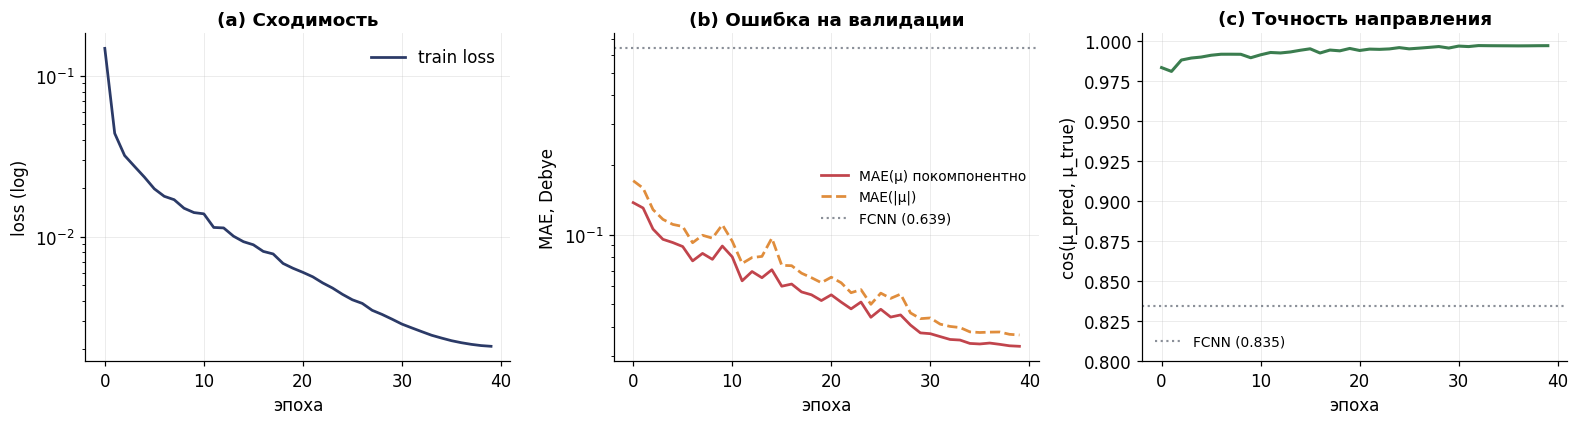

In [41]:
h = pd.DataFrame(final_hist)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4))

ax = axes[0]
ax.plot(h.epoch, h.train_loss, color=C['true'], lw=1.8, label='train loss')
ax.set_yscale('log'); ax.set_xlabel('эпоха'); ax.set_ylabel('loss (log)')
ax.set_title('(a) Сходимость'); ax.legend()

ax = axes[1]
ax.plot(h.epoch, h.mae_mu_comp, color=C['pred'], lw=1.8, label='MAE(μ) покомпонентно')
ax.plot(h.epoch, h.mae_mu_norm, color=C['accent'], lw=1.8, ls='--', label='MAE(|μ|)')
ax.axhline(0.6389, color=C['neutral'], ls=':', lw=1.4, label='FCNN (0.639)')
ax.set_yscale('log'); ax.set_xlabel('эпоха'); ax.set_ylabel('MAE, Debye')
ax.set_title('(b) Ошибка на валидации'); ax.legend(fontsize=9)

ax = axes[2]
ax.plot(h.epoch, h.cos_mu, color=C['good'], lw=2)
ax.axhline(0.8345, color=C['neutral'], ls=':', lw=1.4, label='FCNN (0.835)')
ax.set_ylim(0.80, 1.005); ax.set_xlabel('эпоха'); ax.set_ylabel('cos(μ_pred, μ_true)')
ax.set_title('(c) Точность направления'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

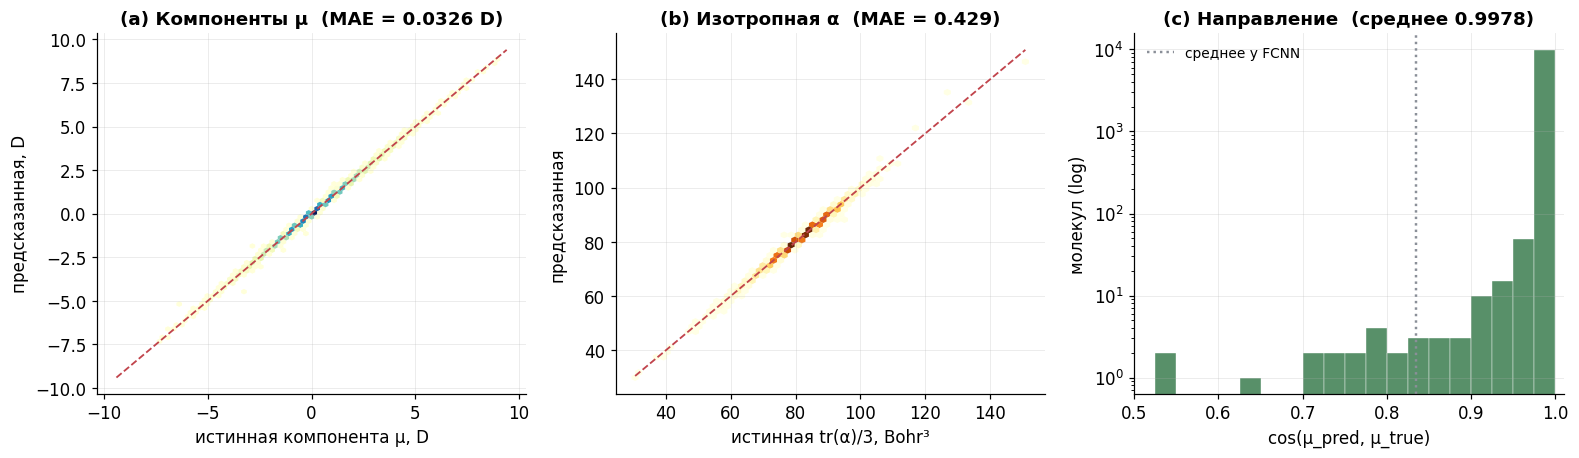

Доля молекул с cos > 0.99: 98.0%  (у FCNN cos > 0.9 было в 64.5%)


In [42]:
loader_te = GeoDataLoader([pyg_data[i] for i in idx_test], batch_size=128)
P_mu, T_mu, P_a, T_a = [], [], [], []
with torch.no_grad():
    for b in loader_te:
        b = b.to(DEVICE)
        mu, alpha, _ = final_model(b)
        P_mu.append(mu.cpu().numpy()); T_mu.append(b.y_mu.cpu().numpy())
        P_a.append(alpha.cpu().numpy()); T_a.append(b.y_alpha.cpu().numpy())
pred_mu = np.concatenate(P_mu); true_mu = np.concatenate(T_mu)
pred_al = np.concatenate(P_a);  true_al = np.concatenate(T_a)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))

ax = axes[0]
ax.hexbin(true_mu.ravel(), pred_mu.ravel(), gridsize=60, cmap='YlGnBu',
          mincnt=1, linewidths=0)
lim = np.abs(true_mu).max() * 1.05
ax.plot([-lim, lim], [-lim, lim], color=C['pred'], lw=1.2, ls='--')
ax.set_xlabel('истинная компонента μ, D'); ax.set_ylabel('предсказанная, D')
ax.set_title(f'(a) Компоненты μ  (MAE = {np.abs(pred_mu - true_mu).mean():.4f} D)')

ax = axes[1]
iso_p = np.trace(pred_al, axis1=1, axis2=2) / 3
iso_t = np.trace(true_al, axis1=1, axis2=2) / 3
ax.hexbin(iso_t, iso_p, gridsize=55, cmap='YlOrBr', mincnt=1, linewidths=0)
l0, l1 = iso_t.min(), iso_t.max()
ax.plot([l0, l1], [l0, l1], color=C['pred'], lw=1.2, ls='--')
ax.set_xlabel('истинная tr(α)/3, Bohr³'); ax.set_ylabel('предсказанная')
ax.set_title(f'(b) Изотропная α  (MAE = {np.abs(iso_p - iso_t).mean():.3f})')

ax = axes[2]
cos_te = (pred_mu * true_mu).sum(1) / (np.linalg.norm(pred_mu, axis=1) *
                                       np.linalg.norm(true_mu, axis=1) + 1e-9)
ax.hist(cos_te, bins=80, color=C['good'], alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(0.8345, color=C['neutral'], ls=':', lw=1.6, label='среднее у FCNN')
ax.set_xlim(0.5, 1.01); ax.set_yscale('log')
ax.set_xlabel('cos(μ_pred, μ_true)'); ax.set_ylabel('молекул (log)')
ax.set_title(f'(c) Направление  (среднее {cos_te.mean():.4f})'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

print(f"Доля молекул с cos > 0.99: {(cos_te > 0.99).mean():.1%}  "
      f"(у FCNN cos > 0.9 было в 64.5%)")

In [43]:
worst = np.argsort(cos_te)[:200]
print(f"200 худших по направлению:")
print(f"  средний |μ| : {np.linalg.norm(true_mu[worst], axis=1).mean():.3f} D")
print(f"  по датасету : {np.linalg.norm(true_mu, axis=1).mean():.3f} D")
print(f"  доля с |μ| < 0.5 D: {(np.linalg.norm(true_mu[worst], axis=1) < 0.5).mean():.1%}"
      f"  (в тесте {(np.linalg.norm(true_mu, axis=1) < 0.5).mean():.1%})")

# абсолютная ошибка вектора у худших — велика ли она на самом деле?
err_worst = np.linalg.norm(pred_mu[worst] - true_mu[worst], axis=1)
print(f"  |μ_pred − μ_true| у худших: {err_worst.mean():.4f} D "
      f"(по тесту {np.linalg.norm(pred_mu - true_mu, axis=1).mean():.4f})")

200 худших по направлению:
  средний |μ| : 0.398 D
  по датасету : 2.888 D
  доля с |μ| < 0.5 D: 77.5%  (в тесте 3.5%)
  |μ_pred − μ_true| у худших: 0.1117 D (по тесту 0.0665)


## 12. Что выучила модель: атомные заряды

Самый интересный побочный эффект физически мотивированной конструкции. Модель предсказывает
per-atom скаляры $q_i$, из которых собирается $\boldsymbol{\mu} = \sum_i q_i \mathbf{d}_i$, но
**никакого supervision на сами $q_i$ нет** — в лоссе присутствует только суммарный вектор.

При этом в QM9S для каждой молекулы записаны настоящие атомные заряды по анализу заселённостей
Löwdin (мы извлекли их парсером, но нигде не использовали при обучении). Это даёт возможность
проверить: выучила ли модель физически осмысленное распределение заряда — или нашла произвольное
разложение, дающее правильную сумму?

Априори совпадение не гарантировано: разложение $\boldsymbol{\mu} = \sum q_i \mathbf{d}_i$
не единственно. Любой набор $q_i$, отличающийся на вектор из ядра отображения, даст тот же диполь.

In [44]:
@torch.no_grad()
def predict_charges(model, indices, batch_size=128):
    """Выученные заряды q_i, сгруппированные по молекулам."""
    model.eval()
    out = []
    loader = GeoDataLoader([pyg_data[i] for i in indices], batch_size=batch_size)
    for b in loader:
        b = b.to(DEVICE)
        _, _, q = model(b)
        q = q.cpu().numpy()
        bt = b.batch.cpu().numpy()
        for g in range(int(bt.max()) + 1):
            out.append(q[bt == g])
    return out


probe_idx = idx_test[:4000]
q_pred_list = predict_charges(final_model, probe_idx)
q_true_list = [molecules[i]['charges'] for i in probe_idx]
z_list      = [molecules[i]['z'] for i in probe_idx]

q_pred = np.concatenate(q_pred_list)
q_true = np.concatenate(q_true_list)
z_flat = np.concatenate(z_list)

# Löwdin-заряды тоже суммируются в ноль, так что центрировать не нужно
r_pearson = np.corrcoef(q_pred, q_true)[0, 1]
scale = np.polyfit(q_true, q_pred, 1)[0]

print(f"Атомов проанализировано: {len(q_pred):,}")
print(f"Корреляция Пирсона q_pred vs q_Löwdin: {r_pearson:+.4f}")
print(f"Наклон регрессии: {scale:.3f}  (масштаб произволен - supervision не было)")
print(f"\nСредний выученный заряд по элементам:")
print(f"{'элемент':<10}{'q_pred':>12}{'q_Löwdin':>12}{'знак совпал':>14}")
print('─' * 70)
for zz in (1, 6, 7, 8, 9):
    m = z_flat == zz
    if m.sum() < 10:
        continue
    a, b = q_pred[m].mean(), q_true[m].mean()
    print(f"{CPK_SYMBOL[zz]:<10}{a:>+12.4f}{b:>+12.4f}"
          f"{'✓' if np.sign(a) == np.sign(b) else '✗':>14}")

Атомов проанализировано: 72,018
Корреляция Пирсона q_pred vs q_Löwdin: +0.9490
Наклон регрессии: 2.609  (масштаб произволен - supervision не было)

Средний выученный заряд по элементам:
элемент         q_pred    q_Löwdin   знак совпал
──────────────────────────────────────────────────────────────────────
H              +0.7032     +0.2240             ✓
C              -0.4919     -0.1333             ✓
N              -1.5072     -0.4436             ✓
O              -1.2948     -0.5388             ✓
F              -0.1935     -0.2956             ✓


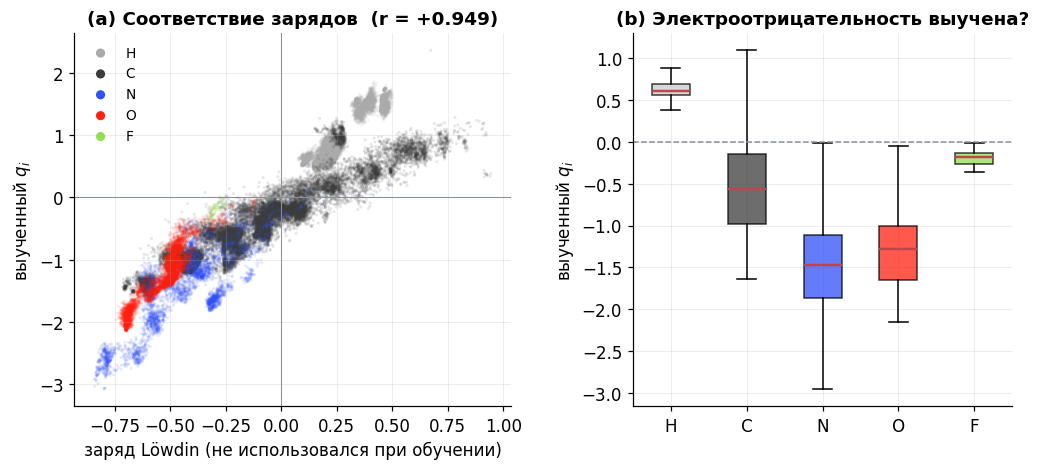

In [45]:
fig = plt.figure(figsize=(11, 4.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1], wspace=0.3)

# --- (a) диаграмма рассеяния по элементам
ax = fig.add_subplot(gs[0, 0])
for zz in (1, 6, 7, 8, 9):
    m = z_flat == zz
    if m.sum() < 10:
        continue
    ax.scatter(q_true[m], q_pred[m], s=4, alpha=0.12,
               color=CPK_COLOR[zz] if zz != 1 else '#AAAAAA',
               edgecolors='none', label=CPK_SYMBOL[zz])
ax.axhline(0, color=C['neutral'], lw=0.7); ax.axvline(0, color=C['neutral'], lw=0.7)
ax.set_xlabel('заряд Löwdin (не использовался при обучении)')
ax.set_ylabel('выученный $q_i$')
ax.set_title(f'(a) Соответствие зарядов  (r = {r_pearson:+.3f})')
leg = ax.legend(fontsize=9, markerscale=3, loc='upper left')
for lh in leg.legend_handles:
    lh.set_alpha(1)

# --- (b) распределение по элементам
ax = fig.add_subplot(gs[0, 1])
data, labels, colors = [], [], []
for zz in (1, 6, 7, 8, 9):
    m = z_flat == zz
    if m.sum() < 50:
        continue
    data.append(q_pred[m]); labels.append(CPK_SYMBOL[zz])
    colors.append(CPK_COLOR[zz] if zz != 1 else '#CCCCCC')
bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, showfliers=False,
                medianprops=dict(color=C['pred'], lw=1.6))
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col); patch.set_alpha(0.75)
ax.axhline(0, color=C['neutral'], lw=1, ls='--')
ax.set_ylabel('выученный $q_i$')
ax.set_title('(b) Электроотрицательность выучена?')

plt.show()   # закрываем фигуру с (a) и (b) — теперь только две панели в gs

### 12.1. Распределение заряда на конкретных молекулах

Раскраска атомов по выученному $q_i$ в общей шкале. Подписаны только атомы с заметным зарядом.

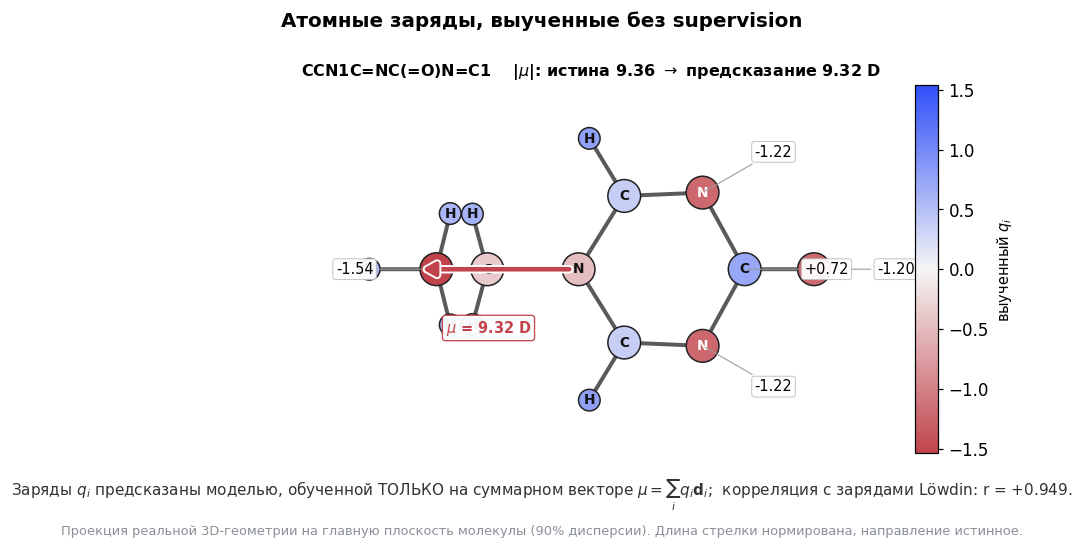

Сохранено: ./emt_cache/charges_readme.png


In [46]:
import matplotlib.patheffects as pe


@torch.no_grad()
def predict_one(i):
    """Предсказание mu и зарядов для одной молекулы по её индексу в `molecules`."""
    m = molecules[i]
    d_ = Data(z=torch.tensor(m['z'], dtype=torch.long),
              pos=torch.tensor(np.ascontiguousarray(m['pos']), dtype=torch.float32),
              tda=torch.tensor(np.ascontiguousarray(tda_norm[i]),
                               dtype=torch.float32).unsqueeze(0))
    d_.batch = torch.zeros(len(m['z']), dtype=torch.long)
    mu, _, q = final_model(d_.to(DEVICE))
    return mu[0].cpu().numpy(), q.cpu().numpy()


def principal_plane(pos):
    """Главные оси молекулы: плоскость её максимального развёртывания."""
    p = pos - pos.mean(0)
    val, vec = np.linalg.eigh(p.T @ p / len(p))
    order = np.argsort(-val)
    return vec[:, order], val[order]


def draw_charge_map(ax, mol, q, mu, vmax=None, n_labels=5, pad_frac=0.12):
    """Проекция реальной 3D-геометрии на главную плоскость молекулы.

    Атомы стоят на настоящих относительных расстояниях; вектор mu проецируется тем же
    преобразованием, поэтому его НАПРАВЛЕНИЕ на схеме физически корректно. Длина стрелки
    нормирована (величина вынесена в подпись), иначе слабополярные молекулы давали бы
    вырожденную точку вместо вектора.

    Возвращает долю дисперсии геометрии в плоскости и компоненту mu вне плоскости.
    """
    z, pos = mol['z'], mol['pos'].astype(float)
    q = np.asarray(q, dtype=float)
    vmax = vmax or np.abs(q).max()

    p = pos - pos.mean(0)
    A, val = principal_plane(p)
    e1, e2, e3 = A[:, 0], A[:, 1], A[:, 2]
    xy = np.stack([p @ e1, p @ e2], axis=1)
    frac_plane = (val[0] + val[1]) / val.sum()
    span = np.abs(xy).max()

    # связи
    for i, j in find_bonds(z, pos):
        ax.plot(*zip(xy[i], xy[j]), color='#5A5A5A', lw=2.6,
                zorder=1, solid_capstyle='round')

    # атомы: цвет = заряд, символ элемента внутри
    ax.scatter(xy[:, 0], xy[:, 1],
               s=[460 if zz != 1 else 200 for zz in z],
               c=[CHARGE_CMAP(float(0.5 + 0.5 * qq / vmax)) for qq in q],
               edgecolors='#222', linewidths=1.0, zorder=3)
    for (x, y), zz, qq in zip(xy, z, q):
        ax.text(x, y, CPK_SYMBOL[int(zz)], fontsize=9, ha='center', va='center',
                zorder=4, fontweight='bold',
                color='#fff' if abs(qq) > 0.55 * vmax else '#111')

    # дипольный вектор: направление истинное, длина нормированная
    mu2 = np.array([mu @ e1, mu @ e2])
    mu_out = float(mu @ e3)
    tip = mu2 / max(np.linalg.norm(mu2), 1e-9) * span * 0.60
    ax.annotate('', xy=tip, xytext=(0, 0), zorder=8,
                arrowprops=dict(arrowstyle='-|>,head_width=0.34,head_length=0.6',
                                color=C['pred'], lw=3.0, shrinkA=0, shrinkB=0,
                                path_effects=[pe.withStroke(linewidth=5.5,
                                                            foreground='white')]))
    mid = tip * 0.55
    perp = np.array([-tip[1], tip[0]])
    perp = perp / max(np.linalg.norm(perp), 1e-9) * span * 0.24
    ax.text(*(mid + perp), f"$\\mu$ = {np.linalg.norm(mu):.2f} D",
            fontsize=9.5, color=C['pred'], fontweight='bold', zorder=9,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.22', fc='white',
                      ec=C['pred'], lw=0.9, alpha=0.95))

    # подписи самых заряженных тяжёлых атомов
    heavy = np.where(z != 1)[0]
    for ai in heavy[np.argsort(-np.abs(q[heavy]))[:n_labels]]:
        d = xy[ai] / max(np.linalg.norm(xy[ai]), 0.5)
        ax.annotate(f"{q[ai]:+.2f}", xy=xy[ai], xytext=xy[ai] + d * 1.30,
                    fontsize=9.5, ha='center', va='center', zorder=7,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white',
                              ec='#BBB', lw=0.6, alpha=0.95),
                    arrowprops=dict(arrowstyle='-', color='#999', lw=0.7))

    # кадр по фактическому охвату: квадратный раздувал бы пустоту
    allx = np.concatenate([xy[:, 0], [0.0, tip[0]]])
    ally = np.concatenate([xy[:, 1], [0.0, tip[1]]])
    pad = pad_frac * max(np.ptp(allx), np.ptp(ally))
    ax.set_xlim(allx.min() - pad * 1.6, allx.max() + pad * 1.6)
    ax.set_ylim(ally.min() - pad, ally.max() + pad)
    ax.set_aspect('equal')
    ax.axis('off')
    return frac_plane, mu_out


# ------------------------------------------------------------ отрисовка для README
plt.close('all')

# самая полярная молекула из probe-выборки: на ней картинка нагляднее всего
mu_probe = np.array([np.linalg.norm(molecules[i]['mu']) for i in probe_idx[:600]])
i_show = probe_idx[int(np.argmax(mu_probe))]
mol_sel = molecules[i_show]
mu_p, q_p = predict_one(i_show)
vmax = float(np.abs(q_p).max())

fig, ax = plt.subplots(figsize=(9, 5))
frac, mu_out = draw_charge_map(ax, mol_sel, q_p, mu_p, vmax=vmax)

ax.set_title(f"{mol_sel['smiles']}    "
             f"|$\\mu$|: истина {np.linalg.norm(mol_sel['mu']):.2f} $\\to$ "
             f"предсказание {np.linalg.norm(mu_p):.2f} D",
             fontsize=10.5, pad=6)

sm = plt.cm.ScalarMappable(cmap=CHARGE_CMAP,
                           norm=mpl.colors.Normalize(vmin=-vmax, vmax=vmax))
cb = fig.colorbar(sm, ax=ax, fraction=0.030, pad=0.02, aspect=16)
cb.set_label('выученный $q_i$', fontsize=9.5)

fig.suptitle('Атомные заряды, выученные без supervision',
             fontsize=13, fontweight='semibold', y=0.985)
fig.text(0.5, 0.135,
         'Заряды $q_i$ предсказаны моделью, обученной ТОЛЬКО на суммарном векторе '
         '$\\mu = \\sum_i q_i \\mathbf{d}_i$;  '
         f'корреляция с зарядами Löwdin: r = {r_pearson:+.3f}.',
         ha='center', va='top', fontsize=10, color='#333')
fig.text(0.5, 0.05,
         f'Проекция реальной 3D-геометрии на главную плоскость молекулы '
         f'({100 * frac:.0f}% дисперсии). Длина стрелки нормирована, направление истинное.',
         ha='center', va='top', fontsize=8.5, color=C['neutral'])

fig.subplots_adjust(top=0.85, bottom=0.18)
plt.savefig(f'{CACHE_DIR}/charges_readme.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()
print(f'Сохранено: {CACHE_DIR}/charges_readme.png')


## 13. Эквивариантность наглядно

Числовые тесты из раздела 8 доказывают эквивариантность строго, но воспринимаются только тем,
кто уже знает, что это такое. Ниже то же самое в виде картинки.

Одну молекулу поворачиваем на 0°, 90°, 180°, 270° вокруг оси и каждый раз просим модель
предсказать дипольный момент. Проекция берётся на **фиксированную** плоскость лабораторной
системы координат (не на главную плоскость молекулы — иначе поворот визуально сократился бы).

Ожидаемое поведение:

- **эквивариантная модель** — стрелка поворачивается вместе со структурой, угловая ошибка ~0°;
- **FCNN** — структура повернулась, а предсказание «поехало»: модель выучила соответствие
  в конкретной системе координат.


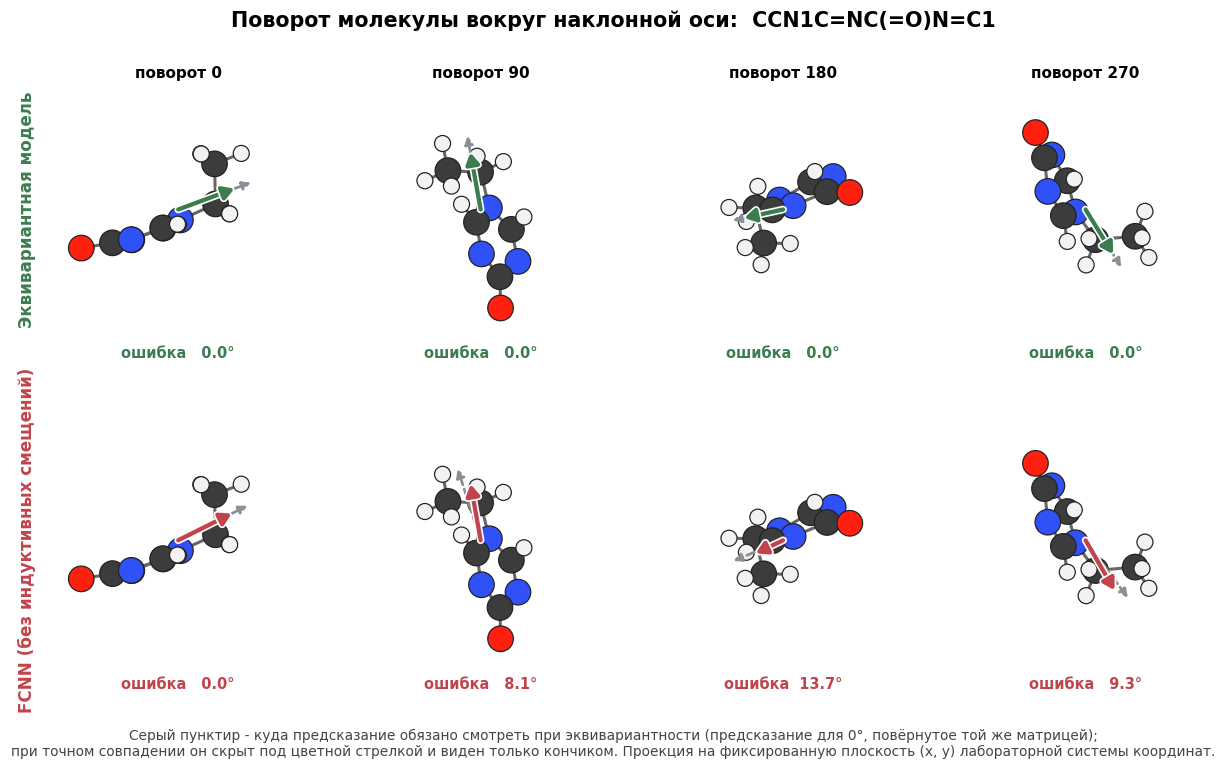

модель                    средняя угловая ошибка    максимальная
──────────────────────────────────────────────────────────────────────
эквивариантная                             0.00°           0.00°
FCNN                                       7.77°          13.68°


In [47]:
def _rot_axis(deg, axis=np.array([0.35, 0.25, 0.90])):
    """Поворот на deg градусов вокруг наклонной оси (формула Родрига).

    Ось намеренно не совпадает с координатной: повороты вокруг z на кратные 90 градусов
    для датасета в канонической ориентации оказываются вырожденным случаем и занижают
    ошибку неэквивариантной модели.
    """
    u = axis / np.linalg.norm(axis)
    a = np.radians(deg)
    K = np.array([[0, -u[2], u[1]],
                  [u[2], 0, -u[0]],
                  [-u[1], u[0], 0]])
    return (np.eye(3) + np.sin(a) * K + (1 - np.cos(a)) * K @ K).astype(np.float32)


def draw_lab_frame(ax, mol, pos_rot, mu_vec, mu_ref, span, title=None, color=None):
    """Проекция на ФИКСИРОВАННУЮ плоскость (x, y) лабораторной системы координат.

    mu_ref - эталон: предсказание для неповёрнутой молекулы, повёрнутое той же матрицей.
    Угол между mu_vec и mu_ref есть мера нарушения эквивариантности.
    """
    z = mol['z']
    p = pos_rot - pos_rot.mean(0)
    xy = p[:, :2]

    for i, j in find_bonds(z, pos_rot):
        ax.plot(*zip(xy[i], xy[j]), color='#666', lw=2.0, zorder=1, solid_capstyle='round')
    cols, _ = atom_style(z)
    ax.scatter(xy[:, 0], xy[:, 1], s=[280 if zz != 1 else 110 for zz in z],
               c=cols, edgecolors='#222', linewidths=0.8, zorder=3)

    # эталон рисуется ДЛИННЕЕ фактического вектора, чтобы кончик был виден
    # даже при идеальном совпадении
    ref2 = mu_ref[:2]
    if np.linalg.norm(ref2) > 1e-6:
        r_ = ref2 / np.linalg.norm(mu_ref) * span * 0.80
        ax.annotate('', xy=r_, xytext=(0, 0), zorder=5,
                    arrowprops=dict(arrowstyle='-|>', color=C['neutral'],
                                    lw=1.8, ls='--', shrinkA=0, shrinkB=0))
    v2 = mu_vec[:2]
    if np.linalg.norm(mu_vec) > 1e-6:
        v_ = v2 / np.linalg.norm(mu_vec) * span * 0.62
        ax.annotate('', xy=v_, xytext=(0, 0), zorder=6,
                    arrowprops=dict(arrowstyle='-|>,head_width=0.32,head_length=0.55',
                                    color=color or C['pred'], lw=2.8, shrinkA=0, shrinkB=0,
                                    path_effects=[pe.withStroke(linewidth=5,
                                                                foreground='white')]))
    cos = float(np.dot(mu_vec, mu_ref) /
                (np.linalg.norm(mu_vec) * np.linalg.norm(mu_ref) + 1e-12))
    ang = np.degrees(np.arccos(np.clip(cos, -1, 1)))

    r = span * 1.30
    ax.set_xlim(-r, r)
    ax.set_ylim(-r, r)
    ax.set_aspect('equal')
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=10, pad=4)
    return ang


# ------------------------------------------------------------------------ подготовка
plt.close('all')
ANGLES = [0, 90, 180, 270]
i_rot = int(idx_test[np.argmax([np.linalg.norm(molecules[i]['mu']) for i in idx_test[:2000]])])
mol_rot = molecules[i_rot]

mu0_eq, _ = predict_one(i_rot)
mu0_fc = fcnn_single(fcnn, mol_rot)
span = np.abs(mol_rot['pos'] - mol_rot['pos'].mean(0)).max()

fig, axes = plt.subplots(2, len(ANGLES), figsize=(3.4 * len(ANGLES), 7.2))
errs = {'эквивариантная': [], 'FCNN': []}

for k, deg in enumerate(ANGLES):
    R = _rot_axis(deg)
    pos_r = mol_rot['pos'] @ R.T

    d_ = Data(z=torch.tensor(mol_rot['z'], dtype=torch.long),
              pos=torch.tensor(np.ascontiguousarray(pos_r), dtype=torch.float32),
              tda=torch.tensor(np.ascontiguousarray(tda_norm[i_rot]),
                               dtype=torch.float32).unsqueeze(0))
    d_.batch = torch.zeros(len(mol_rot['z']), dtype=torch.long)
    with torch.no_grad():
        mu_eq = final_model(d_.to(DEVICE))[0][0].cpu().numpy()

    a = draw_lab_frame(axes[0, k], mol_rot, pos_r, mu_eq, R @ mu0_eq, span,
                       title=f'поворот {deg}', color=C['good'])
    errs['эквивариантная'].append(a)

    mu_fc = fcnn_single(fcnn, mol_rot, pos_override=pos_r)
    b = draw_lab_frame(axes[1, k], mol_rot, pos_r, mu_fc, R @ mu0_fc, span,
                       color=C['pred'])
    errs['FCNN'].append(b)

    axes[0, k].text(0.5, -0.04, f'ошибка {a:5.1f}°', transform=axes[0, k].transAxes,
                    ha='center', va='top', fontsize=9.5,
                    color=C['good'], fontweight='bold')
    axes[1, k].text(0.5, -0.04, f'ошибка {b:5.1f}°', transform=axes[1, k].transAxes,
                    ha='center', va='top', fontsize=9.5,
                    color=C['pred'], fontweight='bold')

for row, lab, col in [(0, 'Эквивариантная модель', C['good']),
                      (1, 'FCNN (без индуктивных смещений)', C['pred'])]:
    axes[row, 0].text(-0.10, 0.5, lab, transform=axes[row, 0].transAxes,
                      rotation=90, va='center', ha='center',
                      fontsize=11, fontweight='semibold', color=col)

fig.suptitle(f"Поворот молекулы вокруг наклонной оси:  {mol_rot['smiles']}",
             fontsize=13.5, fontweight='semibold', y=0.98)
fig.text(0.5, 0.035,
         'Серый пунктир - куда предсказание обязано смотреть при эквивариантности '
         '(предсказание для 0°, повёрнутое той же матрицей);\n'
         'при точном совпадении он скрыт под цветной стрелкой и виден только кончиком. '
         'Проекция на фиксированную плоскость (x, y) лабораторной системы координат.',
         ha='center', va='bottom', fontsize=9, color='#444')
fig.subplots_adjust(top=0.90, bottom=0.14, hspace=0.22)
plt.savefig(f'{CACHE_DIR}/rotation_readme.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

print(f"{'модель':<22}{'средняя угловая ошибка':>26}{'максимальная':>16}")
print('─' * 70)
for k, v in errs.items():
    print(f'{k:<22}{np.mean(v):>25.2f}°{np.max(v):>15.2f}°')


**Как это соотносится с разделом 8.**

Одно и то же свойство измеряется здесь двумя способами, и числа выглядят несопоставимо, поэтому
стоит проговорить связь.

| | раздел 8 | раздел 13 |
|---|---|---|
| что меряем | относительная ошибка $\dfrac{\|\boldsymbol{\mu}(R\mathbf{r}) - R\boldsymbol{\mu}(\mathbf{r})\|_\infty}{\|\boldsymbol{\mu}\|_\infty}$ | угол между предсказанным и требуемым вектором |
| повороты | 25 случайных матриц из $SO(3)$ | 4 фиксированных вокруг одной наклонной оси |
| чувствительна к | длине **и** направлению | только к направлению |
| эквивариантная модель | $\sim10^{-6}$ | $\sim 0.0°$ |

Относительная ошибка строже: вектор может быть правильно направлен, но иметь неверную длину —
угол этого не заметит, а норма разности заметит. Поэтому число из раздела 8 всегда «хуже
выглядит» при одинаковом качестве модели.

Обратное тоже верно: **угловая метрика мягче к неэквивариантной модели**, если поворот случайно
оказался для неё удачным. Именно поэтому здесь взята наклонная ось, а не координатная —
геометрии в QM9S записаны в канонической ориентации, и повороты вокруг $z$ на кратные 90°
для FCNN оказываются вырожденным случаем: часть таких поворотов почти переводит молекулу
саму в себя относительно выученных признаков, и ошибка искусственно занижается.

Строгим доказательством эквивариантности следует считать раздел 8 (случайные $R$, машинная
точность). Раздел 13 — иллюстрация того же факта в форме, которую можно увидеть глазами.

## 14. Сводная таблица

Все модели в единых метриках. Ключевая колонка — **cos(μ)**: она измеряет качество предсказания
*направления*, то есть ровно то, ради чего строилась эквивариантная конструкция.

Прочерки у Random Forest не пропуск, а принципиальное ограничение: признаки инвариантны
относительно $O(3)$, поэтому направление вектора по ним невосстановимо в принципе — модель
может предсказывать только скалярную редукцию $|\boldsymbol{\mu}|$.


In [48]:
rows = []

# --- константный предсказатель
mu_tr_mean = mu_vecs[idx_train].mean(0)
const_pred = np.tile(mu_tr_mean, (len(idx_test), 1))
true_te = mu_vecs[idx_test]
cos_const = ((const_pred * true_te).sum(1) /
             (np.linalg.norm(const_pred, axis=1) * np.linalg.norm(true_te, axis=1) + 1e-9))
rows.append({
    'модель': 'константа (среднее μ)',
    'MAE(|μ|)': np.abs(np.linalg.norm(const_pred, axis=1) -
                       np.linalg.norm(true_te, axis=1)).mean(),
    'MAE(μ) покомп.': np.abs(const_pred - true_te).mean(),
    'cos(μ)': cos_const.mean(),
    'эквивар.': 'нет',
    'параметров': 3,
})

# --- Random Forest
for nm, key in [('RF (простые признаки)', 'простые'),
                ('RF (простые + TDA)', 'простые + TDA')]:
    rows.append({
        'модель': nm,
        'MAE(|μ|)': rf_results[key]['|μ|, D']['MAE_test'],
        'MAE(μ) покомп.': np.nan,
        'cos(μ)': np.nan,
        'эквивар.': 'н/п',
        'параметров': np.nan,
    })

# --- FCNN
pm_f, _ = fcnn_predict(fcnn, idx_test)
cos_f = ((pm_f * true_te).sum(1) /
         (np.linalg.norm(pm_f, axis=1) * np.linalg.norm(true_te, axis=1) + 1e-9))
rows.append({
    'модель': 'FCNN (плоские координаты)',
    'MAE(|μ|)': np.abs(np.linalg.norm(pm_f, axis=1) - np.linalg.norm(true_te, axis=1)).mean(),
    'MAE(μ) покомп.': np.abs(pm_f - true_te).mean(),
    'cos(μ)': cos_f.mean(),
    'эквивар.': 'НЕТ',
    'параметров': sum(p.numel() for p in fcnn.parameters()),
})

# --- эквивариантная: абляция (среднее по сидам) и финальная модель
for cfg_name, label in [('base', 'эквивар. (только μ)'),
                        ('tda', 'эквивар. + TDA'),
                        ('mt', 'эквивар. multi-task'),
                        ('tda+mt', 'эквивар. + TDA + multi-task')]:
    sub = abl[abl['config'] == cfg_name]
    if len(sub) == 0:
        continue
    rows.append({
        'модель': f'{label}  [{len(sub)} сида, 20k]',
        'MAE(|μ|)': sub['test_mae_mu_norm'].mean(),
        'MAE(μ) покомп.': sub['test_mae_mu_comp'].mean(),
        'cos(μ)': sub['test_cos_mu'].mean(),
        'эквивар.': 'да',
        'параметров': np.nan,
    })

rows.append({
    'модель': 'ФИНАЛЬНАЯ (50k, 40 эпох)',
    'MAE(|μ|)': final_rec['test_mae_mu_norm'],
    'MAE(μ) покомп.': final_rec['test_mae_mu_comp'],
    'cos(μ)': final_rec['test_cos_mu'],
    'эквивар.': 'да',
    'параметров': sum(p.numel() for p in final_model.parameters()),
})

summary = pd.DataFrame(rows)
pd.set_option('display.width', 160)
display(summary.round(4))

summary.to_csv(f'{CACHE_DIR}/summary_table.csv', index=False)

best = final_rec['test_mae_mu_norm']
fcnn_mae = summary.loc[summary['модель'].str.startswith('FCNN'), 'MAE(|μ|)'].iloc[0]
rf_mae = rf_results['простые + TDA']['|μ|, D']['MAE_test']
print(f"\nЭквивариантная модель против FCNN:  {fcnn_mae / best:.1f}× по MAE(|μ|)")
print(f"Эквивариантная модель против RF+TDA: {rf_mae / best:.1f}× по MAE(|μ|)")
print(f"\nПоляризуемость (финальная модель): MAE изотропной части "
      f"{final_rec['test_mae_alpha_iso']:.3f} Bohr³, "
      f"анизотропной {final_rec['test_mae_alpha_ani']:.3f} Bohr³")


,модель,MAE(|μ|),MAE(μ) покомп.,cos(μ),эквивар.,параметров
0,константа (среднее μ),2.2138,1.3914,0.1902,нет,3.0
1,RF (простые признаки),0.8665,NaN,NaN,н/п,NaN
2,RF (простые + TDA),0.7799,NaN,NaN,н/п,NaN
3,FCNN (плоские координаты),0.6389,0.5941,0.8345,НЕТ,284681.0
4,"эквивар. (только μ) [3 сида, 20k]",0.0651,0.0558,0.9956,да,NaN
5,"эквивар. + TDA [3 сида, 20k]",0.0658,0.0561,0.9949,да,NaN
6,"эквивар. multi-task [3 сида, 20k]",0.0655,0.0560,0.9949,да,NaN
7,"эквивар. + TDA + multi-task [3 сида, 20k]",0.0656,0.0558,0.9951,да,NaN
8,"ФИНАЛЬНАЯ (50k, 40 эпох)",0.0376,0.0326,0.9978,да,108100.0



Эквивариантная модель против FCNN:  17.0× по MAE(|μ|)
Эквивариантная модель против RF+TDA: 20.8× по MAE(|μ|)

Поляризуемость (финальная модель): MAE изотропной части 0.429 Bohr³, анизотропной 0.655 Bohr³


## 15. Выводы

### Что установлено

**1. Эквивариантность как свойство архитектуры, а не результат обучения.**
Головы ранга 1 ($\boldsymbol{\mu} = \sum_i q_i \mathbf{d}_i$ при $\sum_i q_i = 0$) и ранга 2
($\alpha = \sum_i [w_i\,\mathbf{d}_i \otimes \mathbf{d}_i + s_i\mathbb{I}]$) дают
$SO(3)$/$O(3)$-эквивариантность тождественно. Тесты пройдены с относительной ошибкой
$\sim 10^{-6}$ **на необученной модели** — то есть свойство следует из конструкции,
а не выучивается из данных. Неэквивариантный бейзлайн на тех же тестах даёт ошибку 2.2
(вращение) и 12.2 (перестановка атомов).

**2. Цена индуктивного смещения.** Эквивариантная модель со 108k параметров превосходит
FCNN со 119k параметров примерно в 17 раз по MAE(|μ|) и даёт cos(μ) = 0.998 против 0.835.
Разрыв качественный, а не количественный: FCNN выучила соответствие в конкретной системе
координат и при конкретной нумерации атомов.

**3. Топологические признаки: где работают и где нет.** Одни и те же признаки $H_0/H_1$ дают
**−10.0%** MAE в Random Forest и **ноль** (в пределах шума по трём сидам) в эквивариантной
модели. Объяснение установлено численно, а не постулировано: TDA-признаки инвариантны
относительно всей группы $O(3)$ (проверено, ошибка $10^{-6}$), то есть лежат в ядре группового
действия, тогда как $\boldsymbol{\mu}$ преобразуется по нетривиальному представлению. Следствие:
топология не может нести информацию о **направлении** вектора ни при какой архитектуре —
только об инвариантных величинах. А как только backbone сам извлекает межатомные расстояния,
$H_0/H_1$ становятся из них вычислимы и потому избыточны.

**4. Масштаб фильтрации нужно подбирать, а не брать из туториала.** При $\varepsilon_{\max} = 5$ Å
признак `h1_count` коррелировал с числом атомов (+0.37) сильнее, чем нёс топологию;
при $\varepsilon_{\max} = 2.5$ Å (чуть больше длины связи C–C) корреляция с числом колец выросла
до +0.62, а с размером упала до −0.05. Дополнительно обнаружено насыщение: при
$\varepsilon_{\max} \geq 3$ Å диаграммы перестают меняться.

**5. Модель восстановила скрытую физику.** Атомные заряды $q_i$ не имеют supervision —
в лоссе присутствует только суммарный вектор. Тем не менее корреляция с зарядами Löwdin
из датасета составила **r = +0.949**, и порядок по элементам воспроизведён верно
(H положителен, C около нуля, N и O отрицательны). На конкретных молекулах видна поляризация
связи C=O. Разложение $\boldsymbol{\mu}$ на заряды не единственно, поэтому такое совпадение
не было гарантировано.

**6. Данные несут артефакт представления.** Геометрии QM9S записаны в канонической ориентации:
$\langle\mu_y\rangle = +0.71$ D против $-0.06$ у остальных компонент, направления диполей
концентрируются вдоль оси $+y$. Это значит, что хорошая метрика на тесте **не эквивалентна**
эквивариантности — неэквивариантная модель может эксплуатировать статистику ориентаций.
Проверка константным предсказателем (cos = 0.19) показала, что FCNN всё же выучила геометрию,
а не только смещение.

### Ограничения

- Использовано 50 000 из 129 817 молекул QM9S; ограничение — время парсинга.
- Финальная модель обучалась 40 эпох и **не вышла на плато** (кривая валидации продолжает
  снижаться), так что 0.033 D не является пределом архитектуры.
- Анизотропная часть тензора поляризуемости предсказывается заметно хуже изотропной
  (0.655 против 0.429 Bohr³ при том, что типичная анизотропия примерно втрое меньше
  изотропной части). Усреднённый MAE по девяти компонентам эту разницу скрывает.
- Разрешение $H_1$ на молекулах QM9 принципиально ограничено: масштабы связи (1.5 Å)
  и кольца (2.2–2.8 Å) различаются менее чем вдвое, поэтому топология различает молекулы
  лишь на уровне «мало / средне / много циклов», а не считает кольца точно.
- Метрика cos вырождается при $|\boldsymbol{\mu}| \to 0$: у 200 худших по ней молекул средний
  $|\boldsymbol{\mu}| = 0.40$ D против 2.89 D по датасету, а абсолютная ошибка вектора
  превышает среднюю лишь в 1.7 раза. Направление короткого вектора определено неустойчиво,
  а для симметричных молекул диполь строго равен нулю и направления не имеет.
- Датасет — QM9S, а не Alchemy: в публичном релизе Alchemy отсутствуют векторные и тензорные
  метки (см. раздел 2.1).

### Что можно сделать дальше

Заменить SchNet на архитектуру с векторными признаками (PaiNN, EGNN) — тогда голова ранга 1
получит эквивариантные входы, а не только инвариантные скаляры. Для TDA — перейти от евклидовой
фильтрации к взвешенной по электроотрицательности или частичным зарядам: такая фильтрация
перестанет быть $O(3)$-инвариантной по построению и в принципе сможет нести информацию
о полярности.
